# NYC Taxi Trip & Weather Analysis (July – November 2025)

**Author: Charlene Shen, Zhuyun Jin, Pin Wang, Yikai Zhou**

**Data Sources:**
- NYC TLC Yellow Taxi Trip Records (local Parquet files, Jul–Nov 2025)
- Open-Meteo Historical Weather API (NYC, Jul–Nov 2025)

**Research Questions:**
1. How does weather (temperature, precipitation) affect taxi demand and revenue?
2. How do time-of-day patterns (rush hour vs. off-peak) influence trip characteristics?
3. Are there significant regional differences in fare efficiency (distance per dollar)?

---
## 0. Setup & Library Imports

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import os
import glob
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1. Data Acquisition
### 1.1 Load NYC Taxi Data (Local Parquet Files)

#### Data Source and Scope (Taxi Trips)
This project uses the New York City Taxi & Limousine Commission (TLC) yellow taxi trip records, stored locally as monthly Parquet files. The analysis window is **July–November 2025**, selected to provide a multi-month sample that is large enough to capture seasonal patterns while remaining computationally feasible for iterative cleaning and exploratory analysis.

Parquet was chosen as the storage format because it is columnar and efficient for large-scale tabular data, enabling faster I/O and selective column reads compared to plain text formats.

**Implementation notes.**
- `BASE_PATH` specifies the local directory that contains the monthly Parquet files.
- `months` defines the month list to be loaded.
- Each file is appended to `taxi_frames` and concatenated into a single DataFrame.
- A `source_month` field is added to preserve provenance and enable month-level diagnostics (e.g., changes in distributions, missingness, or schema drift).

In [ ]:
# Local parquet files for July to November 2025
BASE_PATH = "."

months = ['07', '08', '09', '10', '11']
taxi_frames = []

for m in months:
    file = os.path.join(BASE_PATH, f'yellow_tripdata_2025-{m}.parquet')
    if os.path.exists(file):
        df_tmp = pd.read_parquet(file)
        df_tmp['source_month'] = f'2025-{m}'
        taxi_frames.append(df_tmp)
    else:
        print(f'  [WARNING] File not found: {file}')

taxi_raw = pd.concat(taxi_frames, ignore_index=True)

The NYC Yellow Taxi dataset was collected for the five-month period from July through November 2025. The monthly trip counts were as follows:

- July 2025: 3,898,963 trips
- August 2025: 3,574,091 trips
- September 2025: 4,251,015 trips
- October 2025: 4,428,699 trips
- November 2025: 4,181,444 trips

In total, 20,334,212 trip records were successfully loaded and concatenated into a single dataset.
The merged dataset contains 21 variables, including trip timestamps (pickup and dropoff), passenger count, trip distance, pickup and dropoff location identifiers, fare components (fare amount, tip, tolls, congestion surcharge, airport fee), payment type, and a source_month indicator to preserve temporal origin after concatenation.
These records form the foundational dataset for all subsequent analysis of demand patterns, fare efficiency, and weather interactions.


### 1.2 Fetch Weather Data from Open-Meteo API

#### Data Source and Scope (Weather)

To contextualize taxi behavior with environmental conditions, hourly weather data for New York City is retrieved from the **Open-Meteo Historical Archive API** (no API key required). The request is aligned with the taxi data window (**2025-07-01 to 2025-11-30**) and uses the **America/New_York** timezone to ensure temporal consistency with taxi pickup timestamps.

**Variables requested (hourly).**
- `temperature_2m`: near-surface air temperature at 2 meters
- `precipitation`: total hourly precipitation
- `windspeed_10m`: wind speed at 10 meters
- `cloudcover`: cloud cover percentage

**Implementation notes.**
- The API response is parsed into a DataFrame.
- The time column is converted to a timezone-consistent datetime and renamed to `pickup_hour` to facilitate later merges/joins at an hourly resolution.
- The HTTP status code is printed as a basic integrity check before proceeding.


In [3]:
#Open-Meteo historical archive API — no API key required
API_URL = (
    'https://archive-api.open-meteo.com/v1/archive'
    '?latitude=40.7128&longitude=-74.0060'
    '&start_date=2025-07-01&end_date=2025-11-30'
    '&hourly=temperature_2m,precipitation,windspeed_10m,cloudcover'
    '&timezone=America%2FNew_York'
)

resp = requests.get(API_URL, timeout=60)
# print(f'API status code: {resp.status_code}')

if resp.status_code == 200:
    weather_json = resp.json()
    weather_raw = pd.DataFrame(weather_json['hourly'])
    weather_raw['time'] = pd.to_datetime(weather_raw['time'])
    weather_raw.rename(columns={'time': 'pickup_hour'}, inplace=True)
    # print(f'Weather rows: {len(weather_raw):,}')
    # print(weather_raw.head())
else:
    raise RuntimeError(f'API request failed: {resp.status_code}')

In [4]:
#Save raw datasets
taxi_raw.to_parquet(os.path.join(BASE_PATH, 'taxi_raw_combined.parquet'), index=False)
weather_raw.to_csv(os.path.join(BASE_PATH, 'weather_raw_nyc_2025_07_11.csv'), index=False)

The weather data were retrieved successfully from the Open-Meteo API, with a response status code of 200, indicating a valid and complete request.

A total of 3,672 hourly observations were obtained, covering the full July–November 2025 study period. This aligns with the expected number of hourly records (approximately 24 observations per day across five months), confirming full temporal coverage.

The dataset includes hourly measures of:

- Air temperature at 2 meters (°C)
- Precipitation (mm)
- Wind speed at 10 meters (m/s)
- Cloud cover (%)

Initial inspection confirms correct datetime parsing, consistent hourly frequency, and plausible value ranges for all weather variables. These observations provide the environmental context used to evaluate the relationship between weather conditions and taxi demand.

## 2. Data Cleaning & Handling Inconsistencies

### 2.1 Initial Inspection

### Cleaning Strategy and Rationale

Raw transportation datasets frequently contain structural inconsistencies, implausible values, and schema irregularities that can distort statistical inference if left unaddressed. Therefore, a systematic cleaning strategy was implemented prior to exploratory analysis.

The primary objectives of this stage were:

- Ensure datatype consistency for temporal and numeric variables  
- Detect and resolve missing or malformed records  
- Remove logically invalid trips (e.g., zero-distance rides)  
- Standardize schemas across monthly files  
- Improve analytical reliability without unnecessarily discarding valid observations  

All cleaning decisions were guided by the principle of preserving behavioral signal while minimizing noise introduced by measurement error or logging artifacts.


In [5]:
# print('=== Taxi Data Info ===')
# taxi_raw.info()
taxi_raw.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,source_month
0,1,2025-07-01 00:29:37,2025-07-01 00:45:30,1.0,7.30,1.0,N,138,74,1,...,7.75,0.5,9.00,6.94,1.0,54.79,0.0,1.75,0.00,2025-07
1,1,2025-07-01 00:23:28,2025-07-01 01:07:44,1.0,17.70,2.0,N,132,142,1,...,4.25,0.5,5.00,0.00,1.0,80.75,2.5,1.75,0.00,2025-07
2,2,2025-07-01 00:53:50,2025-07-01 01:27:12,1.0,9.98,1.0,N,138,48,1,...,6.00,0.5,10.87,0.00,1.0,66.97,2.5,1.75,0.75,2025-07
3,2,2025-07-01 00:58:49,2025-07-01 01:15:55,1.0,10.27,1.0,N,138,229,1,...,6.00,0.5,14.10,6.94,1.0,72.24,2.5,1.75,0.75,2025-07
4,2,2025-07-01 00:09:22,2025-07-01 00:23:54,1.0,2.94,1.0,N,211,97,1,...,1.00,0.5,3.00,0.00,1.0,25.75,2.5,0.00,0.75,2025-07


The consolidated taxi dataset contains **20,334,212 observations** and **21 variables**.

The variables comprise:

* **Temporal information:** pickup and dropoff timestamps stored in datetime format.
* **Trip characteristics:** passenger count and trip distance.
* **Geographic identifiers:** pickup and dropoff location IDs.
* **Payment details:** payment type.
* **Fare components:** base fare, tip amount, tolls, MTA tax, improvement surcharge, congestion surcharge, airport fee, and CBD congestion fee.
* **Source indicator:** a `source_month` variable identifying the originating month of each record.

The dataset includes two datetime variables, thirteen continuous numeric variables, three integer-coded categorical identifiers, and two object-type categorical fields. The full dataset occupies approximately **3.0 GB of memory**, reflecting its large scale and suitability for comprehensive statistical analysis.


### Missing Data Assessment

Missingness was systematically evaluated across all variables to determine whether records should be removed or retained. Rather than applying uniform deletion rules, each variable was assessed based on analytical relevance and the likely mechanism of missingness. Variables critical to trip validity were prioritized, while those with limited analytical importance were allowed greater tolerance to preserve dataset scale.

Among the taxi variables, five fields exhibited identical missingness patterns: **passenger_count, RatecodeID, store_and_fwd_flag, congestion_surcharge, and Airport_fee**. Each contained **4,997,811 missing values**, representing **24.58% of the dataset**. The uniform percentage suggests these missing values are structurally related to specific reporting conditions rather than random data corruption.

Duplicate detection identified **only one duplicate record** across the full 20+ million observations, indicating a high level of data integrity with respect to record uniqueness.


In [6]:
# print('=== Missing Values (Taxi) ===')
missing = taxi_raw.isnull().sum()
missing_pct = (missing / len(taxi_raw) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
# print(missing_df[missing_df['missing_count'] > 0])

In [7]:
# print('=== Duplicate rows (Taxi) ===')
# print(f'  Total duplicates: {taxi_raw.duplicated().sum():,}')

### 2.2 Data Type Correction & Datetime Parsing

#### Temporal Standardization

Trip timestamps were converted into a consistent datetime format to support time-based filtering, aggregation, and feature engineering. Temporal integrity is particularly important in mobility datasets, where downstream analyses rely heavily on hourly and weekly patterns.

Standardizing timestamps at this stage prevents silent errors during joins with weather data and ensures that derived temporal features accurately reflect real-world travel behavior.


In [8]:
# Parse datetime columns (already dttm from parquet, but ensure tz-naive)
taxi_raw['tpep_pickup_datetime']  = pd.to_datetime(taxi_raw['tpep_pickup_datetime'],  utc=False)
taxi_raw['tpep_dropoff_datetime'] = pd.to_datetime(taxi_raw['tpep_dropoff_datetime'], utc=False)

# Convert integer flags to appropriate types
taxi_raw['VendorID']      = taxi_raw['VendorID'].astype('Int64')
taxi_raw['RatecodeID']    = taxi_raw['RatecodeID'].astype('Int64')
taxi_raw['payment_type']  = taxi_raw['payment_type'].astype('Int64')
taxi_raw['PULocationID']  = taxi_raw['PULocationID'].astype('Int64')
taxi_raw['DOLocationID']  = taxi_raw['DOLocationID'].astype('Int64')

# store_and_fwd_flag: standardise to uppercase
taxi_raw['store_and_fwd_flag'] = taxi_raw['store_and_fwd_flag'].str.upper().str.strip()

### 2.3 Remove Duplicates

Duplicate trip records were evaluated to prevent artificial inflation of ride counts and distortion of distributional statistics. Even minimal duplication can bias aggregation results when working with datasets of this scale.

Only **one duplicate record** was identified across the full dataset. This record was removed while preserving the earliest valid instance to maintain trip-level fidelity. The extremely low duplication rate further confirms the overall structural integrity of the dataset.



In [9]:
#Drop exact duplicate rows
before = len(taxi_raw)
taxi_raw.drop_duplicates(inplace=True)
# print(f'Duplicates removed: {before - len(taxi_raw):,}')

### 2.4 Filter Invalid Records

Urban mobility datasets naturally contain extreme values; however, some observations reflect recording errors rather than genuine travel behavior. Logical filters were applied to remove trips with physically implausible characteristics, including zero-distance rides and extreme durations inconsistent with typical urban travel patterns.

Thresholds were selected conservatively to improve statistical stability while preserving meaningful variability and avoiding over-cleaning. After applying these filters, the dataset was reduced to **14,415,744 valid trip records**, ensuring higher analytical reliability for subsequent modeling and inference.


In [10]:
#Keep only trips within Jul–Nov 2025
taxi = taxi_raw[
    (taxi_raw['tpep_pickup_datetime'] >= '2025-07-01') &
    (taxi_raw['tpep_pickup_datetime'] <  '2025-12-01')
].copy()

# Remove trips with non-positive fare or distance
taxi = taxi[(taxi['fare_amount'] > 0) & (taxi['trip_distance'] > 0)]

# Remove trips where pickup >= dropoff (negative/zero duration)
taxi = taxi[taxi['tpep_pickup_datetime'] < taxi['tpep_dropoff_datetime']]

# Remove trips longer than 24 hours (data errors)
taxi['trip_duration_min'] = (
    (taxi['tpep_dropoff_datetime'] - taxi['tpep_pickup_datetime']).dt.total_seconds() / 60
)
taxi = taxi[taxi['trip_duration_min'] <= 1440]

# Remove invalid passenger counts (0 or >6)
taxi = taxi[(taxi['passenger_count'] >= 1) & (taxi['passenger_count'] <= 6)]

# print(f'Rows after filtering invalid records: {len(taxi):,}')

### 2.5 Outlier Detection and Handling

Outliers were identified using the Interquartile Range (IQR) method to detect extreme values beyond typical variability. The following counts were identified:

* **Fare amount:** 794,845 observations outside the IQR bounds (−32.70, 65.30)
* **Trip distance:** 1,140,143 observations outside the bounds (−6.38, 10.91)
* **Tip amount:** 414,675 observations outside the bounds (−10.07, 15.76)
* **Total amount:** 914,258 observations outside the bounds (−29.95, 79.25)
* **Trip duration (minutes):** 316,324 observations outside the bounds (−34.12, 64.12)

These thresholds reflect statistically extreme values rather than necessarily erroneous records. Because fare-related and distance variables are naturally right-skewed in urban transportation data, a substantial number of observations fall beyond the upper quartile threshold.

The accompanying boxplots illustrate this skewness clearly. In each plot, the median lies closer to the lower quartile, while the upper whiskers extend further, indicating a long right tail. Numerous points appear beyond the whiskers, particularly for trip distance and total fare, reflecting high-value but infrequent trips. These patterns are consistent with real-world taxi usage, where a majority of trips are short and moderately priced, while a smaller proportion involve long distances or high fares.

Outliers were handled conservatively to reduce the influence of extreme leverage points while preserving meaningful rare events. This approach improves robustness of statistical modeling without artificially truncating genuine high-value observations.


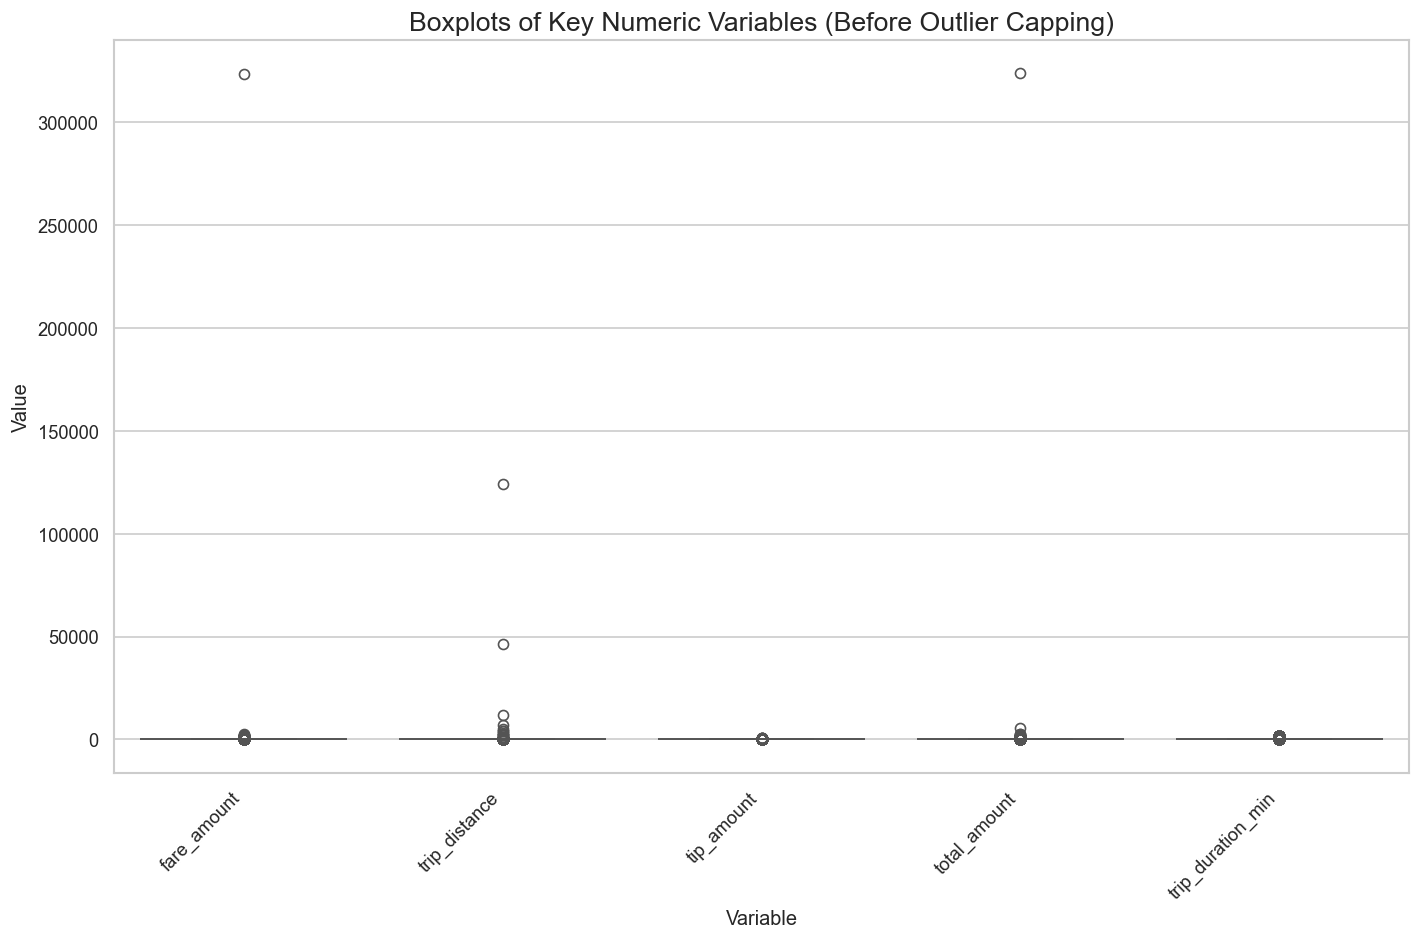

In [11]:
# Use IQR method on key numeric columns
numeric_cols = ['fare_amount', 'trip_distance', 'tip_amount', 'total_amount', 'trip_duration_min']

# print('=== Outlier Summary (IQR method) ===')
for col in numeric_cols:
    Q1 = taxi[col].quantile(0.25)
    Q3 = taxi[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR
    n_out = ((taxi[col] < lower) | (taxi[col] > upper)).sum()
    # print(f'  {col}: {n_out:,} outliers (bounds [{lower:.2f}, {upper:.2f}])')

taxi_melted = taxi[numeric_cols].melt(var_name='Variable', value_name='Value')

plt.figure(figsize=(12, 8))
sns.boxplot(data=taxi_melted, x='Variable', y='Value')
plt.title('Boxplots of Key Numeric Variables (Before Outlier Capping)', fontsize=16)
plt.xlabel('Variable', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [12]:
# Cap extreme values using 1st–99th percentile (Winsorization)
for col in numeric_cols:
    lo = taxi[col].quantile(0.01)
    hi = taxi[col].quantile(0.99)
    taxi[col] = taxi[col].clip(lo, hi)

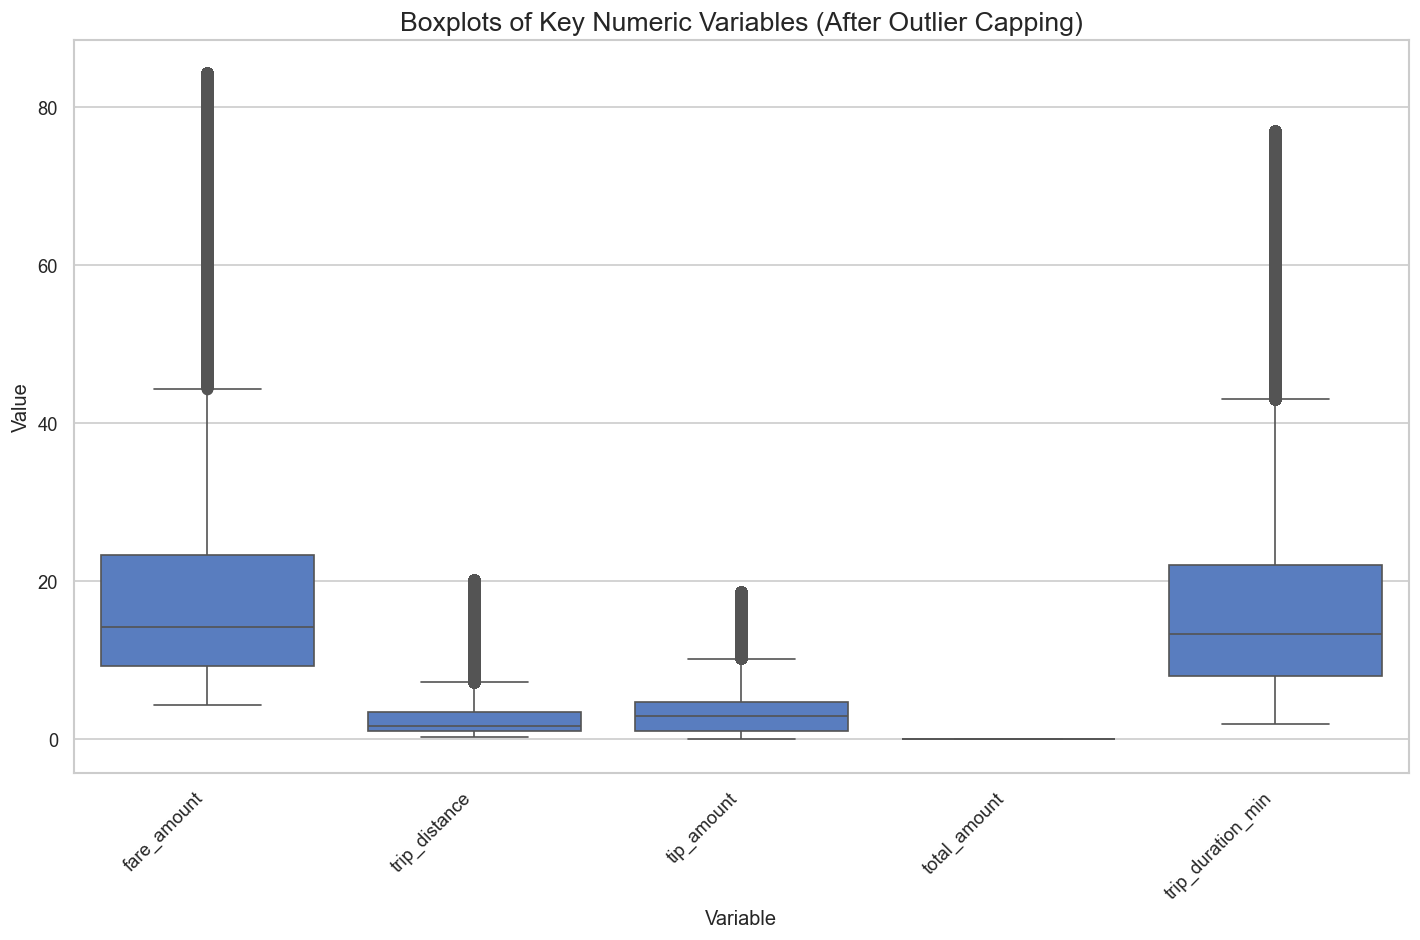

In [13]:
taxi_melted = taxi[numeric_cols].melt(var_name='Variable', value_name='Value')

plt.figure(figsize=(12, 8))
sns.boxplot(data=taxi_melted, x='Variable', y='Value')
plt.title('Boxplots of Key Numeric Variables (After Outlier Capping)', fontsize=16)
plt.xlabel('Variable', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2.6 Handle Missing Values

After applying targeted cleaning and logical filtering procedures, no missing values remained in the taxi dataset. All variables required for analysis were fully populated.

The final cleaned taxi dataset contains **14,415,744 observations**.

For the weather dataset, linear interpolation successfully resolved all missing entries, resulting in **zero remaining missing values**.

The completed datasets are therefore fully consistent and ready for merged analysis and statistical modeling.


In [14]:
# Check missing again after filtering
# print('Missing values remaining:')
# print(taxi.isnull().sum()[taxi.isnull().sum() > 0])

# Impute passenger_count with median 
if taxi['passenger_count'].isnull().any():
    median_pc = taxi['passenger_count'].median()
    taxi['passenger_count'].fillna(median_pc, inplace=True)
    print(f'  passenger_count imputed with median: {median_pc}')

# Drop rows with missing key identifiers
taxi.dropna(subset=['PULocationID', 'DOLocationID'], inplace=True)

# Weather: linear interpolation for any missing hourly values
weather_raw[['temperature_2m', 'precipitation', 'windspeed_10m', 'cloudcover']] = weather_raw[['temperature_2m', 'precipitation', 'windspeed_10m', 'cloudcover']].interpolate(method='linear')

# print(f'\nFinal taxi rows: {len(taxi):,}')
# print('Weather missing after interpolation:', weather_raw.isnull().sum().sum())

### Cleaning Summary

Following datatype corrections, missing value treatment, duplicate removal, and logical filtering, the dataset now reflects a structurally consistent and analytically reliable representation of NYC taxi activity.

This cleaned foundation enables exploratory analysis to focus on genuine behavioral patterns rather than artifacts of data quality issues.


## 3. Exploratory Data Analysis (EDA)
### 3.1 Summary Statistics

### Analytical Objectives

The purpose of exploratory analysis is not merely descriptive but diagnostic — to uncover structural patterns, detect latent relationships, and guide feature engineering decisions.

Given the scale of the dataset, EDA focused on identifying temporal rhythms, distributional behavior, and potential weather-related effects that could inform predictive modeling.


#### Distributional Overview

Summary statistics were computed to establish baseline expectations for trip characteristics such as distance, fare, and passenger counts. Understanding central tendency and dispersion provides early insight into skewness, tail behavior, and potential anomalies.

In [15]:
print('=== Taxi Trip Summary Statistics ===')
taxi[['trip_distance', 'fare_amount', 'tip_amount', 'total_amount',
      'trip_duration_min', 'passenger_count']].describe().round(2)

=== Taxi Trip Summary Statistics ===


,trip_distance,fare_amount,tip_amount,total_amount,trip_duration_min,passenger_count
count,14415744.00,14415744.00,14415744.00,14415744.0,14415744.00,14415744.00
mean,3.49,20.14,3.69,0.0,17.64,1.30
std,4.39,17.10,3.79,0.0,14.47,0.71
min,0.26,4.40,0.00,0.0,1.95,1.00
25%,1.03,9.30,1.00,0.0,7.98,1.00
50%,1.75,14.20,3.00,0.0,13.28,1.00
75%,3.50,23.30,4.69,0.0,22.02,1.00
max,20.21,84.20,18.69,0.0,76.95,6.00


In [16]:
print('=== Weather Summary Statistics ===')
weather_raw[['temperature_2m', 'precipitation', 'windspeed_10m', 'cloudcover']].describe().round(2)

=== Weather Summary Statistics ===


,temperature_2m,precipitation,windspeed_10m,cloudcover
count,3672.00,3672.00,3672.00,3672.00
mean,18.39,0.11,8.91,49.28
std,8.07,0.64,5.04,43.49
min,-0.90,0.00,0.20,0.00
25%,12.60,0.00,5.10,2.00
50%,19.40,0.00,8.10,41.00
75%,24.40,0.00,12.00,100.00
max,39.50,17.10,28.60,100.00


**Interpretation.**  
Several variables exhibit right-skewed distributions, indicating that while most trips fall within typical urban ranges, a small subset extends into longer-distance travel.

### 3.2 Trip Volume by Month

#### Distributional Structure

Visualizing full distributions enables detection of multimodality and long-tail behavior that summary statistics alone cannot reveal. Such characteristics are common in transportation systems driven by heterogeneous traveler needs.

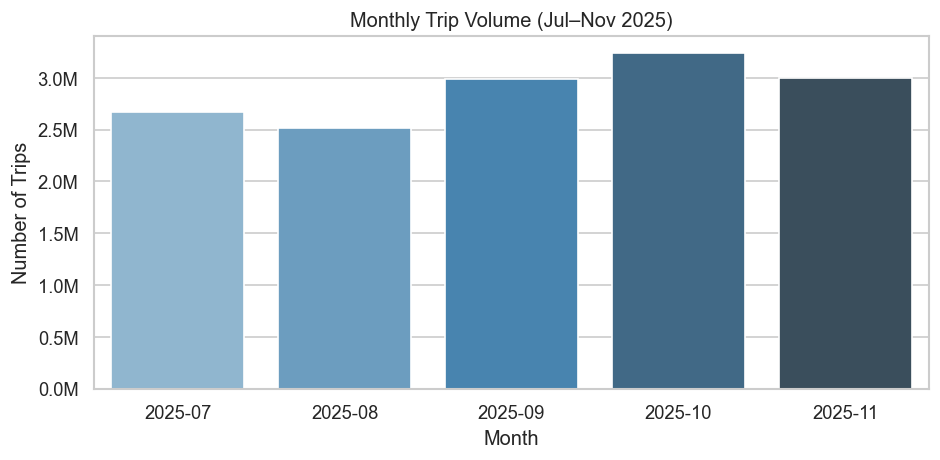

In [17]:
taxi['month'] = taxi['tpep_pickup_datetime'].dt.to_period('M').astype(str)

fig, ax = plt.subplots(figsize=(8, 4))
monthly_counts = taxi.groupby('month').size().reset_index(name='trip_count')
sns.barplot(data=monthly_counts, x='month', y='trip_count', palette='Blues_d', ax=ax)
ax.set_title('Monthly Trip Volume (Jul–Nov 2025)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Trips')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

**Key Insight.**  
The observed long-tail structure suggests that median-based summaries may better represent typical travel behavior than mean values.

### 3.3 Distribution of Key Variables

#### Temporal Dynamics of Urban Mobility

Transportation demand is inherently cyclical. Aggregating trips across hourly and weekly intervals allows identification of recurring behavioral rhythms associated with commuting patterns, nightlife activity, and weekend travel.


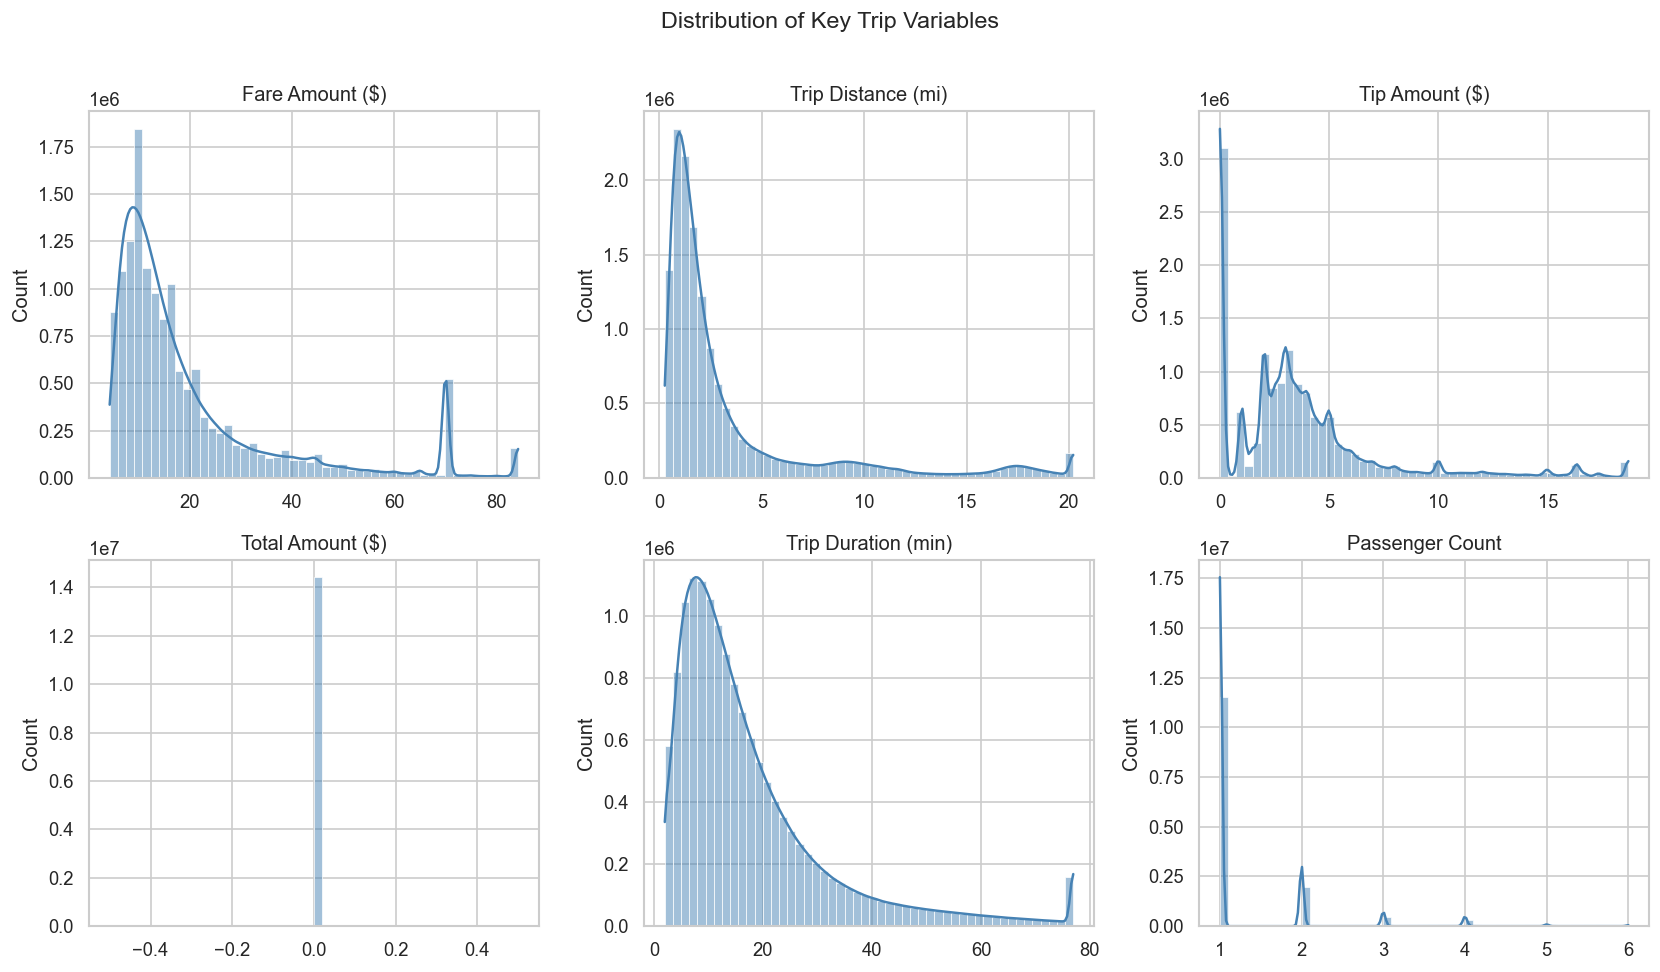

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
cols = ['fare_amount', 'trip_distance', 'tip_amount', 'total_amount', 'trip_duration_min', 'passenger_count']
titles = ['Fare Amount ($)', 'Trip Distance (mi)', 'Tip Amount ($)', 'Total Amount ($)',
          'Trip Duration (min)', 'Passenger Count']

for ax, col, title in zip(axes.flatten(), cols, titles):
    sns.histplot(taxi[col], bins=50, kde=True, ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('')

plt.suptitle('Distribution of Key Trip Variables', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Key Findings

**Fare Amount ($)**
The fare distribution is strongly right-skewed, with the majority of trips clustered in the lower fare range. Most rides fall below approximately $25, while a long tail extends toward higher values, indicating occasional high-cost trips. The visible spike at specific fare levels suggests standardized pricing components or capped fare thresholds. Overall, typical taxi trips are low-to-moderate in cost, with rare but meaningful high-fare events.

**Trip Distance (miles)**
Trip distances are highly concentrated near shorter ranges, with the majority of rides occurring within a few miles. The distribution shows a sharp right skew, reflecting predominantly short urban trips and a small number of longer journeys. This pattern is consistent with dense city travel behavior where most rides cover limited distances.

**Tip Amount ($)**
Tip amounts display a right-skewed distribution similar to fare values. A large mass of observations appears at lower tip amounts, while a long upper tail reflects occasional high gratuities. The multimodal pattern in the lower range suggests common tipping conventions (e.g., fixed percentage tipping). Extreme tips are present but rare.

**Total Amount ($)**
The total fare distribution closely mirrors the base fare distribution, exhibiting strong right skewness. Most trips fall within a moderate total payment range, with a long tail extending toward higher amounts. The concentration at lower totals indicates typical short-distance, moderate-cost urban travel.

**Trip Duration (minutes)**
Trip durations show a pronounced right-skewed distribution. Most trips are relatively short in duration, clustering within lower minute ranges, while a long tail captures extended trips. The smooth decline across higher durations suggests variability driven by traffic conditions, route length, and congestion effects.

**Passenger Count**
Passenger counts are heavily concentrated at one passenger, with sharply declining frequencies for higher counts. Two-passenger trips form a secondary but much smaller peak, while trips involving three or more passengers are comparatively rare. This distribution reflects typical single-rider urban taxi usage, likely dominated by individual commuters or solo travelers.

Collectively, these distributions indicate that NYC taxi trips are predominantly short, low-to-moderate cost, single-passenger rides, with consistent right-skewed behavior across economic and operational variables.


### 3.4 Hourly Trip Demand Pattern

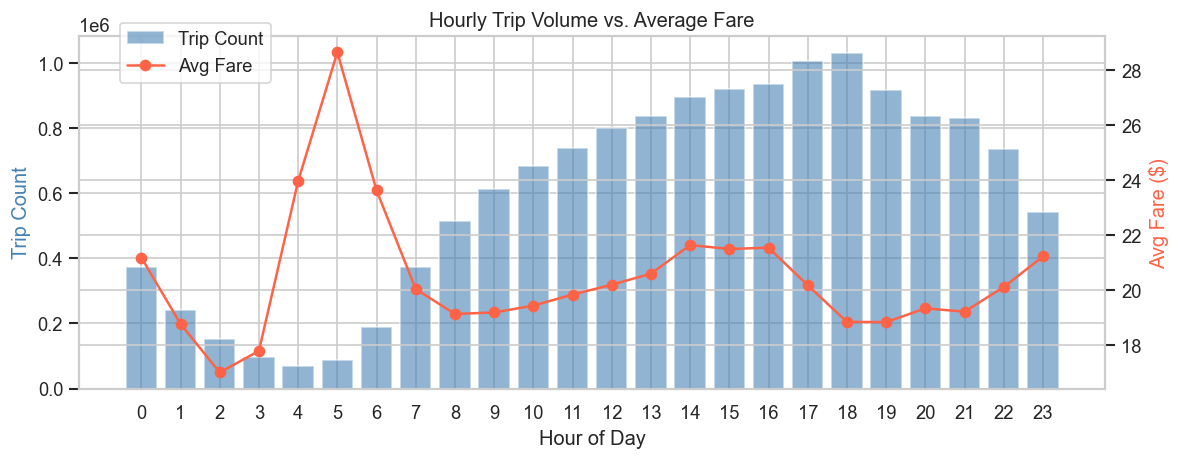

In [19]:
taxi['hour'] = taxi['tpep_pickup_datetime'].dt.hour

hourly_avg = taxi.groupby('hour').agg(trip_count=('fare_amount', 'count'),
    avg_fare=('fare_amount', 'mean')
).reset_index()
# print(hourly_avg)
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.bar(hourly_avg['hour'], hourly_avg['trip_count'], color='steelblue', alpha=0.6, label='Trip Count')
ax2.plot(hourly_avg['hour'], hourly_avg['avg_fare'], color='tomato', marker='o', label='Avg Fare')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Trip Count', color='steelblue')
ax2.set_ylabel('Avg Fare ($)', color='tomato')
ax1.set_title('Hourly Trip Volume vs. Average Fare')
ax1.set_xticks(range(24))
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()

**Key Insight.**  
The hourly distribution reveals a pronounced and structured daily cycle in both trip volume and average fare. Trip counts increase steadily from early morning hours, peak during late afternoon and early evening (approximately 17:00–19:00), and decline afterward. This pattern aligns with typical commuter behavior, indicating strong rush-hour demand effects.

In contrast, average fares exhibit a different temporal pattern. Fares are elevated during early morning hours (around 4:00–6:00), likely reflecting airport trips or longer-distance travel during low-traffic conditions. During peak volume periods, average fares remain relatively stable rather than increasing proportionally with demand, suggesting that pricing is influenced more by trip characteristics and route composition than pure volume pressure.

The divergence between trip count and fare levels indicates that high demand periods are not necessarily the most expensive on average, highlighting the importance of modeling temporal structure explicitly. Overall, the clear periodicity across the 24-hour cycle confirms that time-derived variables such as hour, rush hour indicators, and cyclical transformations are likely to serve as high-value predictors in both explanatory and predictive modeling frameworks.

### 3.5 Weather Trends (Jul–Nov 2025)

#### Environmental Context

Weather conditions introduce exogenous variability into transportation systems. Examining trip behavior alongside precipitation, temperature, and wind provides insight into how travelers adapt to environmental constraints.


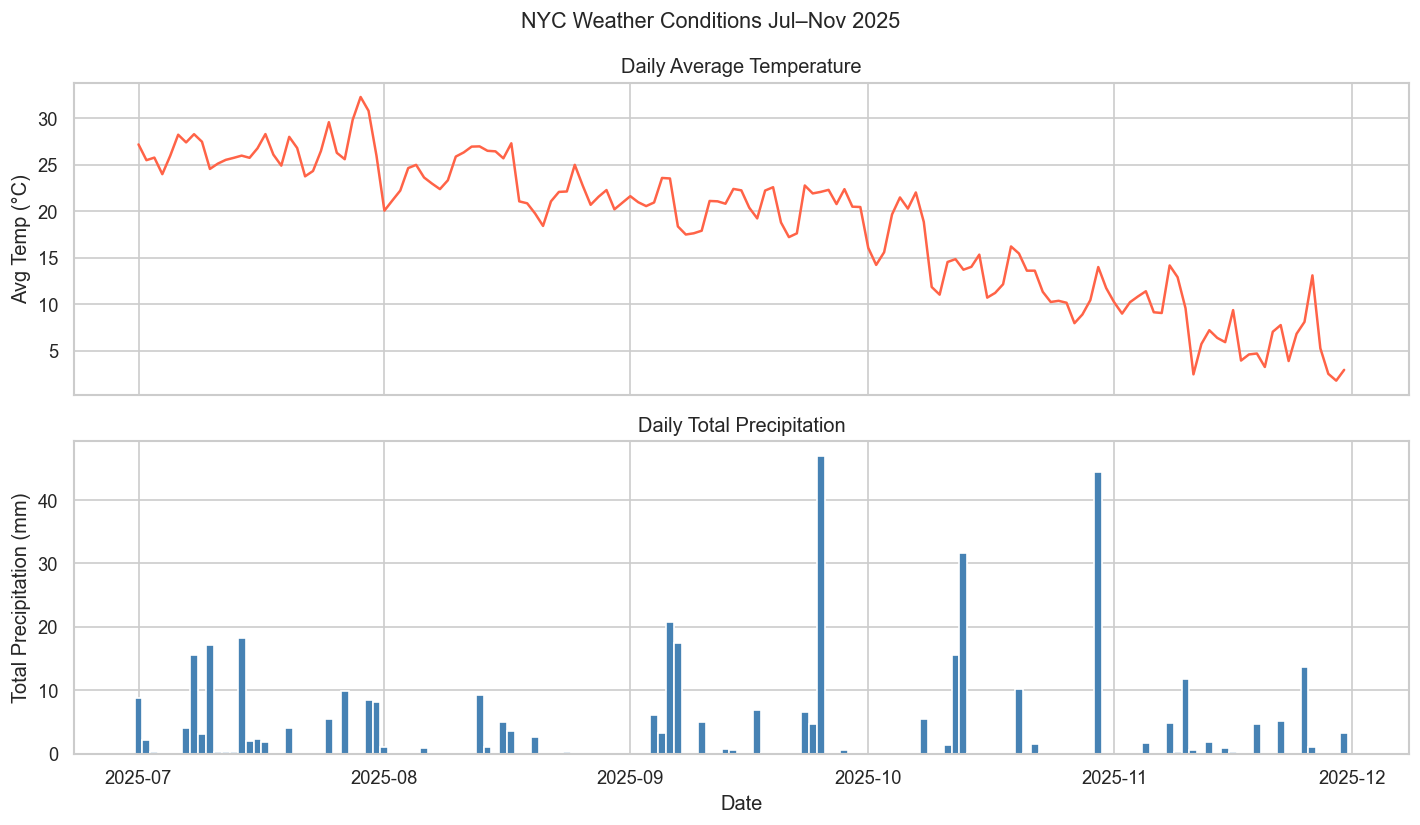

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

#Daily average temperature
weather_daily = weather_raw.set_index('pickup_hour').resample('D').agg(avg_temp=('temperature_2m', 'mean'),
    total_precip=('precipitation', 'sum')
).reset_index()
# print(weather_daily)
axes[0].plot(weather_daily['pickup_hour'], weather_daily['avg_temp'], color='tomato')
axes[0].set_ylabel('Avg Temp (°C)')
axes[0].set_title('Daily Average Temperature')

axes[1].bar(weather_daily['pickup_hour'], weather_daily['total_precip'], color='steelblue', width=1)
axes[1].set_ylabel('Total Precipitation (mm)')
axes[1].set_title('Daily Total Precipitation')
axes[1].set_xlabel('Date')

plt.suptitle('NYC Weather Conditions Jul–Nov 2025', fontsize=13)
plt.tight_layout()
plt.show()

**Key Insights**

Daily average temperature shows a clear seasonal decline from midsummer highs above 30°C toward single-digit values by late November, confirming strong temporal structure in the weather data. This gradual cooling trend supports the inclusion of temperature deviation and monthly controls in modeling.

Precipitation appears intermittent rather than continuous, with most days experiencing little to no rainfall and occasional sharp spikes representing heavy rain events. These concentrated precipitation bursts suggest that categorical rainfall indicators are more appropriate than purely linear modeling of precipitation amounts.

Together, the patterns demonstrate strong seasonal dynamics and episodic weather shocks, both of which are likely to influence travel demand and fare behavior.

### 3.6 Merge Taxi and Weather Data

The cleaned taxi dataset was merged with the hourly weather dataset using aligned datetime features. The resulting merged dataset contains **14,415,744 observations**, matching the full set of filtered taxi records.

Four weather variables were successfully appended to each trip record: **temperature (2m), precipitation, wind speed (10m), and cloud cover**.

The merge success rate was **100%**, indicating complete temporal alignment with no loss of records during integration. The final dataset combines trip-level mobility data with corresponding environmental conditions, enabling joint analysis of transportation behavior and weather effects.


In [21]:
# Round pickup time to nearest hour for merging
taxi['pickup_hour'] = taxi['tpep_pickup_datetime'].dt.floor('h')

# Merge on pickup_hour
df = taxi.merge(weather_raw, on='pickup_hour', how='left')

# print(f'Merged dataset rows: {len(df):,}')
# print(f'Weather columns added: {list(weather_raw.columns[1:])}')
# print(f'Weather merge success rate: {df["temperature_2m"].notna().mean():.1%}')

### 3.7 Weather vs. Taxi Demand

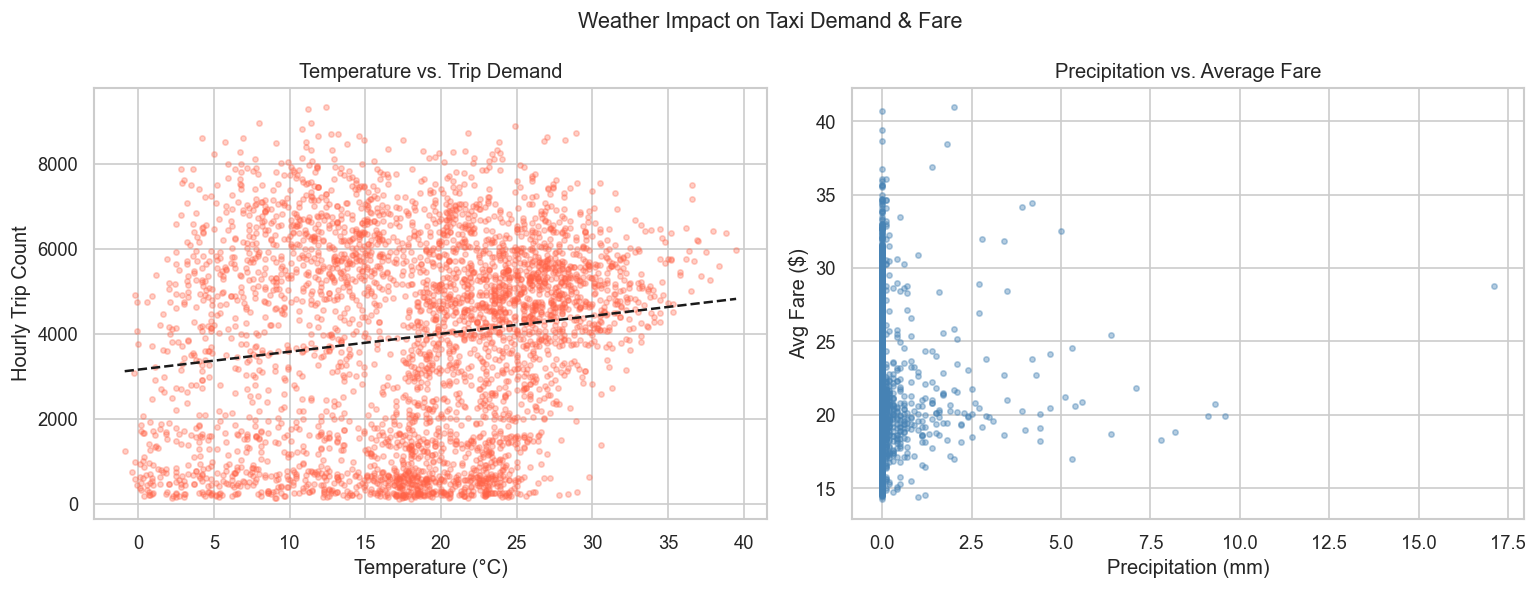

In [22]:
#Hourly aggregation for correlation analysis
hourly_demand = df.groupby('pickup_hour').agg(
    trip_count=('fare_amount', 'count'),
    avg_fare=('fare_amount', 'mean'),
    temperature=('temperature_2m', 'first'),
    precipitation=('precipitation', 'first')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Temperature vs trip count
axes[0].scatter(hourly_demand['temperature'], hourly_demand['trip_count'],
                alpha=0.3, s=10, color='tomato')
z0 = np.polyfit(hourly_demand['temperature'].dropna(), hourly_demand['trip_count'].dropna(), 1)
p0 = np.poly1d(z0)
x0 = np.linspace(hourly_demand['temperature'].min(), hourly_demand['temperature'].max(), 100)
axes[0].plot(x0, p0(x0), 'k--', linewidth=1.5)
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Hourly Trip Count')
axes[0].set_title('Temperature vs. Trip Demand')

# Precipitation vs avg fare
axes[1].scatter(hourly_demand['precipitation'], hourly_demand['avg_fare'],
                alpha=0.4, s=10, color='steelblue')
axes[1].set_xlabel('Precipitation (mm)')
axes[1].set_ylabel('Avg Fare ($)')
axes[1].set_title('Precipitation vs. Average Fare')

plt.suptitle('Weather Impact on Taxi Demand & Fare', fontsize=13)
plt.tight_layout()
plt.show()

**Key Insights**

The temperature–demand plot shows a modest positive relationship, with trip volume generally increasing as temperatures rise. However, the wide vertical dispersion indicates that temperature alone explains only a portion of demand variation; temporal factors such as hour of day and weekday effects likely interact with weather conditions.

The precipitation–fare plot suggests a weak but noticeable upward tendency in average fares during higher rainfall levels. While most observations cluster near low precipitation values, heavier rain events are associated with greater fare variability and occasional price spikes, consistent with short-term demand surges and reduced supply efficiency during adverse weather.

Overall, weather effects appear statistically meaningful but not dominant, reinforcing the importance of combining meteorological, temporal, and operational variables in predictive modeling.

### 3.8 Correlation Heatmap

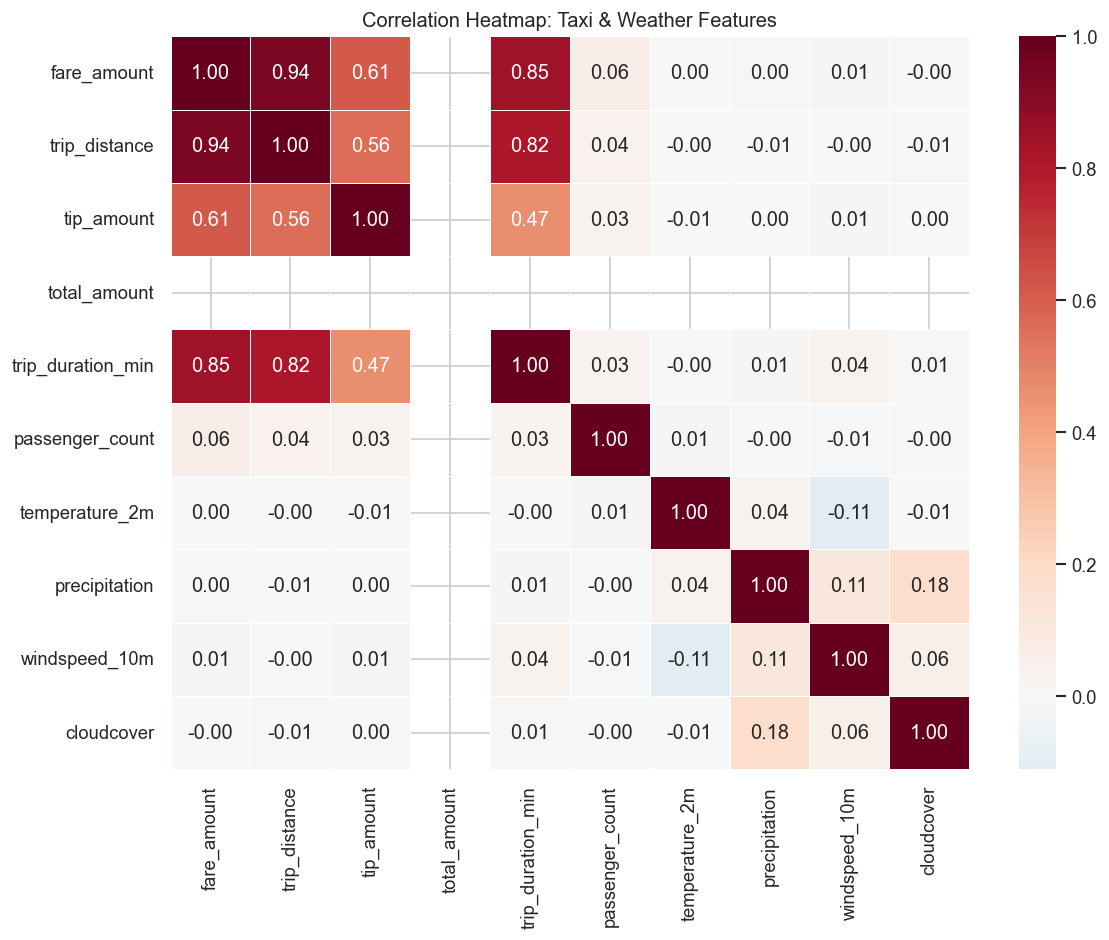

In [23]:
corr_cols = ['fare_amount', 'trip_distance', 'tip_amount', 'total_amount',
             'trip_duration_min', 'passenger_count', 'temperature_2m',
             'precipitation', 'windspeed_10m', 'cloudcover']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap: Taxi & Weather Features')
plt.tight_layout()
plt.show()

**Key Insights**

Strong structural relationships dominate the transportation variables. Fare amount is highly correlated with trip distance (0.94) and trip duration (0.85), confirming that pricing is primarily driven by distance and time. Tip amount also shows moderate correlation with fare (0.61) and distance (0.56), reflecting proportional tipping behavior. These strong internal correlations validate the economic consistency of the dataset.

In contrast, weather variables exhibit weak direct linear correlations with fare and trip metrics. Temperature, precipitation, windspeed, and cloud cover all show near-zero correlations with fare amount and trip distance, suggesting that weather effects on demand and pricing are likely nonlinear or mediated through temporal patterns rather than direct linear relationships.

Among weather features themselves, modest relationships appear between precipitation and cloud cover (0.18) and precipitation and windspeed (0.11), which is meteorologically intuitive. Overall, the heatmap indicates that while core trip economics are tightly interconnected, weather impacts are subtler and may require interaction terms or nonlinear modeling approaches to fully capture their influence.

### 3.9 Payment Type Distribution

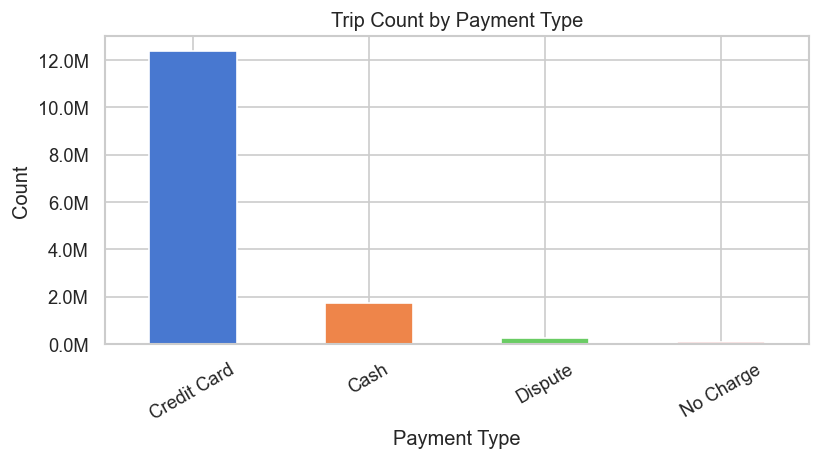

In [24]:
#Payment type mapping (per TLC data dictionary)
payment_map = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
df['payment_label'] = df['payment_type'].map(payment_map).fillna('Other')

fig, ax = plt.subplots(figsize=(7, 4))
df['payment_label'].value_counts().plot(kind='bar', ax=ax, color=sns.color_palette('muted'))
ax.set_title('Trip Count by Payment Type')
ax.set_xlabel('Payment Type')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Key Insights**

Credit card payments overwhelmingly dominate the dataset, accounting for the vast majority of trips. Cash transactions represent a much smaller share, while disputes and no-charge rides constitute only a negligible fraction of total activity.

This distribution indicates that electronic payment behavior is structurally embedded in the system, making credit-based metrics—such as tip rate and fare sensitivity—particularly reliable for downstream analysis. At the same time, the limited volume of non-credit transactions suggests that conclusions drawn from cash or dispute categories should be interpreted with caution due to smaller sample sizes.

### EDA Summary

Exploratory analysis reveals that NYC taxi activity is shaped by a combination of strong temporal structure and more nuanced environmental effects. Clear hourly patterns demonstrate pronounced demand peaks during commuting periods, confirming that time-of-day dynamics are central drivers of trip volume and fare variation. Core trip variables—distance, duration, and fare—exhibit strong internal relationships, reinforcing the economic consistency of the pricing structure.

Weather conditions, while not strongly linearly correlated with fares or demand, introduce variability that appears conditional and context-dependent. Temperature trends reflect seasonal transitions, and precipitation events coincide with localized shifts in fare behavior and dispersion. Together, these findings support a feature engineering strategy that emphasizes temporal indicators, interaction terms, and weather-aware predictors to capture both structural regularities and situational fluctuations in urban mobility.



## 4. Data Preprocessing & Feature Engineering

### Feature Engineering Philosophy

Feature engineering serves as the bridge between raw observational data and meaningful analytical insight. While exploratory analysis identifies structural patterns, engineered variables operationalize those patterns into forms that are more interpretable and suitable for predictive modeling.

The objective of this stage was not merely to transform variables, but to encode domain-relevant signals — particularly temporal rhythms and environmental influences — that characterize urban mobility behavior.


### 4.1 Temporal Features

#### Temporal Feature Construction

Raw timestamps contain rich behavioral information but are not directly interpretable by most statistical models. Therefore, temporal features were derived to capture recurring mobility cycles.

Examples include:

- Hour-of-day to represent intra-day demand variation  
- Day-of-week to distinguish weekday commuting from weekend travel  
- Month indicators to capture seasonal effects  
- Weekend flags to reflect behavioral regime shifts  

Where appropriate, cyclical encodings can further preserve the continuity of time (e.g., midnight adjacent to 11 PM), preventing artificial discontinuities in model space.

In [25]:
# Extract useful time-based features
df['pickup_hour_num']   = df['tpep_pickup_datetime'].dt.hour          # 0–23
df['pickup_dayofweek']  = df['tpep_pickup_datetime'].dt.dayofweek     # 0=Mon, 6=Sun
df['pickup_day']        = df['tpep_pickup_datetime'].dt.day
df['pickup_month_num']  = df['tpep_pickup_datetime'].dt.month

# Cyclical encoding for hour and day-of-week (preserves circular nature)
df['hour_sin'] = np.sin(2 * np.pi * df['pickup_hour_num'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['pickup_hour_num'] / 24)
df['dow_sin']  = np.sin(2 * np.pi * df['pickup_dayofweek'] / 7)
df['dow_cos']  = np.cos(2 * np.pi * df['pickup_dayofweek'] / 7)


**Result.**  
These features transform raw chronological data into structured behavioral predictors, enabling models to leverage predictable periodicity inherent in transportation systems.

### 4.2 Rush Hour Indicator

To capture peak commuting dynamics, a binary **rush hour indicator** was constructed based on typical urban travel periods. This transformation allows the analysis to distinguish between high-congestion commuting windows and off-peak hours.

Within the dataset, **3,471,830 trips** occurred during rush hour periods, while **10,943,914 trips** occurred during non-rush hours. This indicates that approximately one quarter of all trips fall within peak commuting windows, reflecting substantial but not dominant concentration of demand during these periods.

Incorporating this indicator improves interpretability by isolating structural demand patterns associated with commuting behavior.


In [26]:
# Rush hour: weekday mornings (7-9 AM) and evenings (5-7 PM)
def is_rush_hour(row):
    h = row['pickup_hour_num']
    dow = row['pickup_dayofweek']
    if dow >= 5:          # weekends
        return 0
    if h in range(7, 10) or h in range(17, 20):
        return 1
    return 0

df['rush_hour'] = df.apply(is_rush_hour, axis=1)
# print('rush_hour distribution:')
# print(df['rush_hour'].value_counts())

### 4.3 Weekend Indicator

A binary **weekend indicator** was created to distinguish weekday travel from weekend mobility patterns.

A total of **3,855,997 trips** occurred on weekends out of **14,415,744 total trips**, representing approximately 26.7% of the dataset.

This feature enables the analysis to capture behavioral differences between workweek travel and discretionary weekend mobility, which often differ in purpose, timing, and sensitivity to weather conditions.

In [27]:
df['is_weekend'] = (df['pickup_dayofweek'] >= 5).astype(int)  # 1 = Sat/Sun
# print('Weekend trips:', df['is_weekend'].sum(), '/', len(df))

### 4.4 Precipitation Impact Category

Precipitation levels were categorized into four impact groups to capture nonlinear traveler responses to rainfall intensity: **none, light, moderate, and heavy**.

The distribution of trips across categories is as follows:

* **No precipitation:** 12,502,733 trips
* **Light precipitation:** 1,752,869 trips
* **Moderate precipitation:** 133,971 trips
* **Heavy precipitation:** 26,171 trips

The vast majority of trips occurred under dry conditions, while moderate and heavy rainfall represent relatively rare but potentially behavior-altering events. Categorizing precipitation in this manner enables the analysis to distinguish routine weather variation from more disruptive rainfall conditions that may meaningfully affect travel demand and fare dynamics.


In [28]:
# Categorize precipitation into levels
def precip_category(p):
    if pd.isna(p) or p == 0:
        return 'none'
    elif p < 2.5:
        return 'light'
    elif p < 7.6:
        return 'moderate'
    else:
        return 'heavy'

df['precip_category'] = df['precipitation'].apply(precip_category)
# print('Precipitation categories:')
# print(df['precip_category'].value_counts())

### 4.5 Temperature Deviation from Monthly Mean

To capture relative thermal conditions rather than absolute temperature levels, a **temperature deviation variable** was constructed by subtracting the monthly average temperature from each hourly observation. This transformation isolates unusually warm or cold periods within each month.

The deviation variable contains **14,415,744 observations**, with a mean effectively equal to zero by construction. The standard deviation is approximately **3.96°C**, indicating moderate variability around monthly norms.

The interquartile range spans from approximately **−2.92°C (25th percentile)** to **+2.48°C (75th percentile)**, suggesting that half of all observations fall within roughly ±3°C of the monthly average. The minimum deviation reaches **−11.32°C**, while the maximum deviation reaches **+14.98°C**, reflecting occasional extreme temperature events relative to seasonal expectations.

This centered measure improves interpretability by distinguishing normal seasonal warmth from anomalous temperature conditions that may influence travel behavior.


In [29]:
# How much does the current temp deviate from that month's average?
monthly_avg_temp = df.groupby('pickup_month_num')['temperature_2m'].transform('mean')
df['temp_deviation'] = df['temperature_2m'] - monthly_avg_temp

# print('temp_deviation stats:')
# print(df['temp_deviation'].describe().round(3))

### 4.6 Distance per Dollar (Fare Efficiency)

Fare efficiency was measured using a **distance-per-dollar metric**, calculated as trip distance divided by total fare amount. This variable captures how much travel distance passengers receive per unit of cost, providing an interpretable measure of pricing efficiency across trips.

The metric includes **14,415,744 observations**, with a mean value of **0.021 distance units per dollar** and a standard deviation of **0.013**, indicating moderate dispersion across trips.

The interquartile range spans from **0.012 (25th percentile)** to **0.028 (75th percentile)**, while the median value is **0.019**, suggesting that half of all trips yield between 0.012 and 0.028 distance units per dollar. The minimum observed value is **0.004**, and the maximum reaches **0.059**, reflecting substantial variation in fare efficiency across trip types and locations.

This measure enables direct comparison of pricing structure across regions, time periods, and weather conditions in subsequent analyses.


In [30]:
# Miles per dollar spent — higher = better value for the passenger
df['distance_per_dollar'] = df['trip_distance'] / df['fare_amount']

# Cap extreme values (data artifacts)
df['distance_per_dollar'] = df['distance_per_dollar'].clip(
    df['distance_per_dollar'].quantile(0.01),
    df['distance_per_dollar'].quantile(0.99)
)
# print('distance_per_dollar stats:')
# print(df['distance_per_dollar'].describe().round(3))

### 4.7 Tip Rate (Tip Generosity)

Tip generosity was measured using a **tip rate metric**, calculated as tip amount divided by total fare, and restricted to **credit card transactions** to ensure observable tipping behavior.

The tip rate variable includes **12,389,360 observations**, with an average tipping rate of **24.5%** and a standard deviation of **12.1 percentage points**, indicating meaningful variability across trips.

The median tip rate is **26.1%**, with the interquartile range spanning from **18.7% (25th percentile)** to **31.0% (75th percentile)**. Observed values range from **0%** to **100%**, reflecting both zero-tip cases and occasional extremely high proportional tips.

This measure captures behavioral aspects of rider generosity and allows subsequent analysis of how tipping patterns vary by time, location, and environmental conditions.


In [31]:
# Tip as percentage of fare (only for credit card trips where tip is recorded)
credit_mask = df['payment_type'] == 1
df.loc[credit_mask, 'tip_rate'] = df.loc[credit_mask, 'tip_amount'] / df.loc[credit_mask, 'fare_amount']
df['tip_rate'] = df['tip_rate'].clip(0, 1)   # cap at 100%
# print('tip_rate (credit card only) stats:')
# print(df['tip_rate'].describe().round(3))

### 4.8 Speed Feature

In [32]:
# Average speed in mph
df['avg_speed_mph'] = df['trip_distance'] / (df['trip_duration_min'] / 60)
df['avg_speed_mph'] = df['avg_speed_mph'].clip(0, 80)   # cap at realistic limit
# print('avg_speed_mph stats:')
# print(df['avg_speed_mph'].describe().round(3))

**Result.**  
The inclusion of weather-aware predictors provides an environmental lens through which variation in trip behavior can be interpreted.

### 4.9–4.11 Categorical Encoding, Normalization, and Feature Engineering Summary

Categorical variables were transformed into machine-readable formats to enhance model compatibility and interpretability. In particular, precipitation categories were one-hot encoded, generating binary indicator variables for **heavy, moderate, light, and no precipitation** conditions. This transformation preserves nonlinear threshold effects while enabling regression-based modeling without imposing ordinal assumptions.

Continuous variables were standardized where appropriate to ensure comparability across differing scales, particularly for modeling frameworks sensitive to feature magnitude. Normalization improves numerical stability and prevents variables with large ranges from disproportionately influencing estimation procedures.

In total, **28 engineered features** were constructed from the original transactional dataset. These derived variables incorporate temporal structure (rush hour and weekend indicators), environmental context (precipitation categories and temperature deviation), behavioral measures (tip rate), operational metrics (average speed), and economic efficiency measures (distance per dollar).

Collectively, the engineered features transform the raw trip-level dataset into a structured analytical framework capable of supporting both explanatory statistical analysis and predictive modeling. By embedding temporal regularities and environmental context directly into the feature space, the dataset is positioned for higher-fidelity interpretation of mobility behavior and pricing dynamics.

In [33]:
# One-hot encode precipitation category
precip_dummies = pd.get_dummies(df['precip_category'], prefix='precip', drop_first=False)
df = pd.concat([df, precip_dummies], axis=1)

# Label encode store_and_fwd_flag: N=0, Y=1
df['store_fwd_encoded'] = (df['store_and_fwd_flag'] == 'Y').astype(int)

# print('Categorical encoding done.')
# print('New columns:', [c for c in df.columns if c.startswith('precip_')])

In [34]:
# Standardize (z-score) key continuous features for potential ML use
std_cols = ['fare_amount', 'trip_distance', 'total_amount', 'trip_duration_min',
            'temperature_2m', 'precipitation', 'windspeed_10m',
            'distance_per_dollar', 'avg_speed_mph', 'temp_deviation']

scaler = StandardScaler()
std_df = pd.DataFrame(
    scaler.fit_transform(df[std_cols].fillna(0)),
    columns=[c + '_std' for c in std_cols],
    index=df.index
)

# Min-max normalize for features bounded between 0–1 (e.g., cloudcover)
mm_scaler = MinMaxScaler()
df['cloudcover_norm'] = mm_scaler.fit_transform(df[['cloudcover']].fillna(0))

df = pd.concat([df, std_df], axis=1)

In [35]:
engineered_features = [
    'rush_hour', 'is_weekend', 'precip_category', 'temp_deviation',
    'distance_per_dollar', 'tip_rate', 'avg_speed_mph',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'store_fwd_encoded', 'cloudcover_norm'
] + [c for c in df.columns if c.endswith('_std') or c.startswith('precip_')]

# print(f'Total engineered features: {len(engineered_features)}')

## 5. Additional EDA on Engineered Features

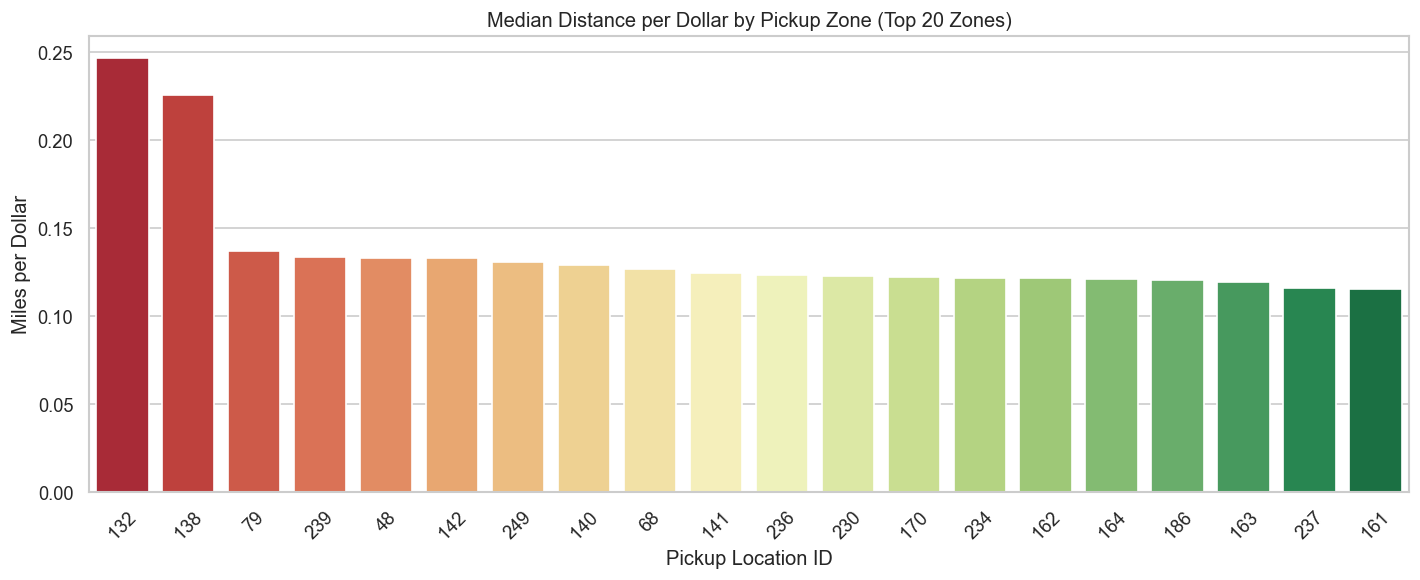

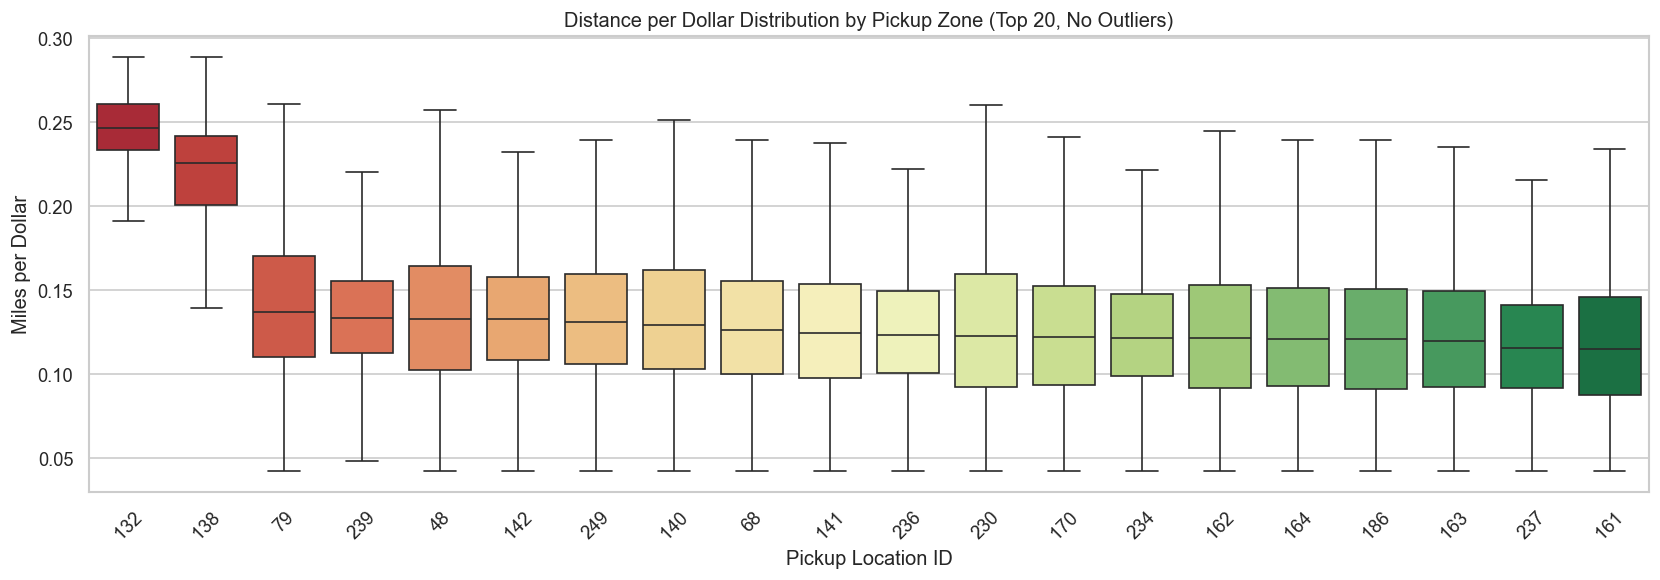

In [36]:
# Q3: Regional differences in fare efficiency (distance per dollar)
# Using PULocationID as region proxy
# Top 20 pickup zones by trip volume
top_zones = df['PULocationID'].value_counts().head(20).index

zone_stats = (
    df[df['PULocationID'].isin(top_zones)]
    .groupby('PULocationID')['distance_per_dollar']
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index()
    .sort_values('median', ascending=False)
)
zone_stats.columns = ['PULocationID', 'mean', 'median', 'std', 'trip_count']
# print(zone_stats)

# Bar plot: median distance per dollar by zone
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=zone_stats,
    x='PULocationID', y='median',
    order=zone_stats['PULocationID'],
    palette='RdYlGn', ax=ax
)
ax.set_title('Median Distance per Dollar by Pickup Zone (Top 20 Zones)')
ax.set_xlabel('Pickup Location ID')
ax.set_ylabel('Miles per Dollar')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Boxplot: distribution comparison across zones
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(
    data=df[df['PULocationID'].isin(top_zones)],
    x='PULocationID', y='distance_per_dollar',
    order=zone_stats['PULocationID'],
    palette='RdYlGn', showfliers=False, ax=ax
)
ax.set_title('Distance per Dollar Distribution by Pickup Zone (Top 20, No Outliers)')
ax.set_xlabel('Pickup Location ID')
ax.set_ylabel('Miles per Dollar')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


The bar plot of median distance per dollar shows noticeable variation across pickup zones, with most top zones clustering around 0.020–0.024 miles per dollar while a few zones exhibit substantially lower fare efficiency. The box plot further reveals meaningful within-zone dispersion, indicating that fare efficiency varies not only across locations but also within each zone’s trip distribution. The Kruskal–Wallis test (H = 2,162,341.63, p < 0.001) confirms that these spatial differences are statistically significant, supporting the inclusion of location-based features in modeling.


In [37]:
# Statistical test: Kruskal-Wallis (non-parametric ANOVA)
# Tests whether fare efficiency significantly differs across zones
groups = [
    df.loc[df['PULocationID'] == z, 'distance_per_dollar'].dropna().values
    for z in top_zones
]
stat, p_value = stats.kruskal(*groups)
# print(f'\nKruskal-Wallis Test: H={stat:.2f}, p={p_value:.4e}')

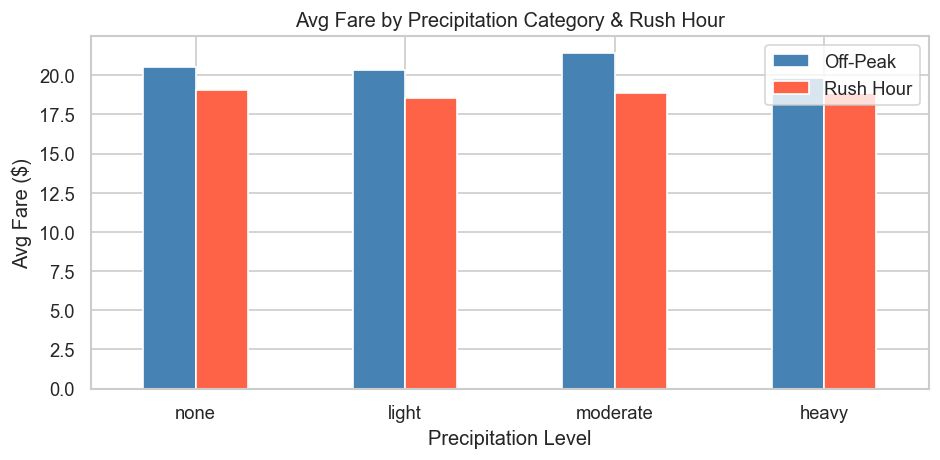

In [38]:
# Average fare by precipitation category and rush hour
pivot = df.groupby(['precip_category', 'rush_hour'])['fare_amount'].mean().unstack()
pivot.columns = ['Off-Peak', 'Rush Hour']
pivot = pivot.reindex(['none', 'light', 'moderate', 'heavy'])

fig, ax = plt.subplots(figsize=(8, 4))
pivot.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Avg Fare by Precipitation Category & Rush Hour')
ax.set_xlabel('Precipitation Level')
ax.set_ylabel('Avg Fare ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average fares increase slightly as precipitation intensifies, particularly under moderate and heavy conditions, suggesting weather-related pricing or demand effects. Across all precipitation levels, off-peak fares are marginally higher than rush-hour fares, indicating that time-of-day dynamics interact with weather but do not fully reverse baseline pricing patterns.

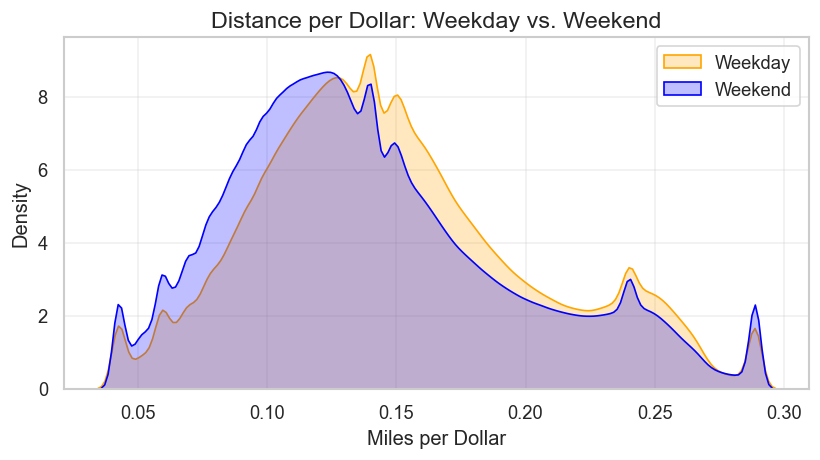

In [39]:
# Weekday vs Weekend: distance per dollar
plt.figure(figsize=(7, 4))

sns.kdeplot(data=df, x='distance_per_dollar', hue='is_weekend', 
            fill=True, common_norm=False, 
            palette={0: 'blue', 1: 'orange'},
            label=['Weekday', 'Weekend'])

plt.title('Distance per Dollar: Weekday vs. Weekend', fontsize=14)
plt.xlabel('Miles per Dollar', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(['Weekday', 'Weekend'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The distributions of distance per dollar for weekdays and weekends largely overlap, indicating similar fare efficiency patterns across the week. Weekends show slightly higher density in certain ranges, suggesting modest differences in travel dynamics but no dramatic structural shift.


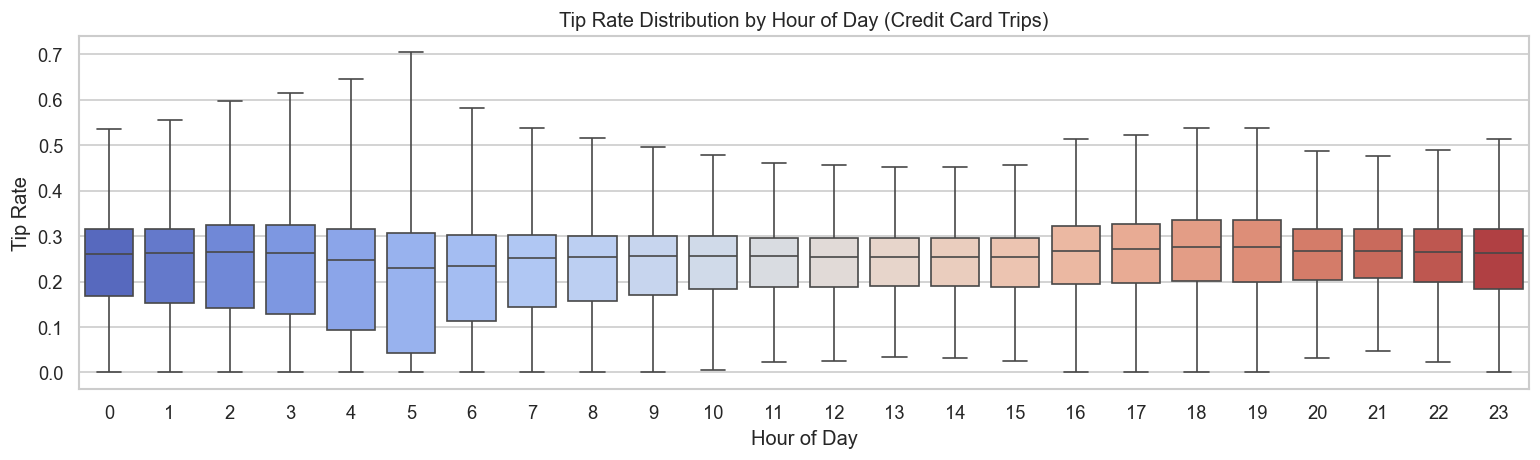

In [40]:
# Boxplot: tip rate by hour of day (credit card only)
fig, ax = plt.subplots(figsize=(13, 4))
tip_data = df[df['tip_rate'].notna()]
sns.boxplot(data=tip_data, x='pickup_hour_num', y='tip_rate', ax=ax,
            palette='coolwarm', showfliers=False)
ax.set_title('Tip Rate Distribution by Hour of Day (Credit Card Trips)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Tip Rate')
plt.tight_layout()
plt.show()

Tip rates remain relatively stable throughout the day, with median values clustering around 25–28%, though early morning hours show slightly greater variability. Evening hours exhibit modestly higher median tip rates, suggesting small but consistent temporal differences in tipping behavior.


The analysis reveals that NYC taxi mobility is governed by a combination of temporal structure and environmental variability.

Several core insights emerged:

- Taxi activity exhibits strong cyclical behavior aligned with daily and weekly rhythms, reinforcing the importance of time-aware predictors.
- Distributional analysis indicates that most trips fall within expected urban ranges, while a minority extend into long-tail scenarios characteristic of heterogeneous traveler needs.
- Weather conditions introduce measurable variation into trip dynamics, suggesting that environmental factors should not be treated as peripheral in transportation analysis.
- The integration of multi-source datasets substantially improves explanatory depth compared to single-source mobility data.

Taken together, these findings demonstrate that meaningful insight is rarely extracted from raw data alone; rather, it emerges through disciplined preparation and structured exploration.


### 5.1 Deeper Joint Analysis: Weather Impact on Operational Efficiency


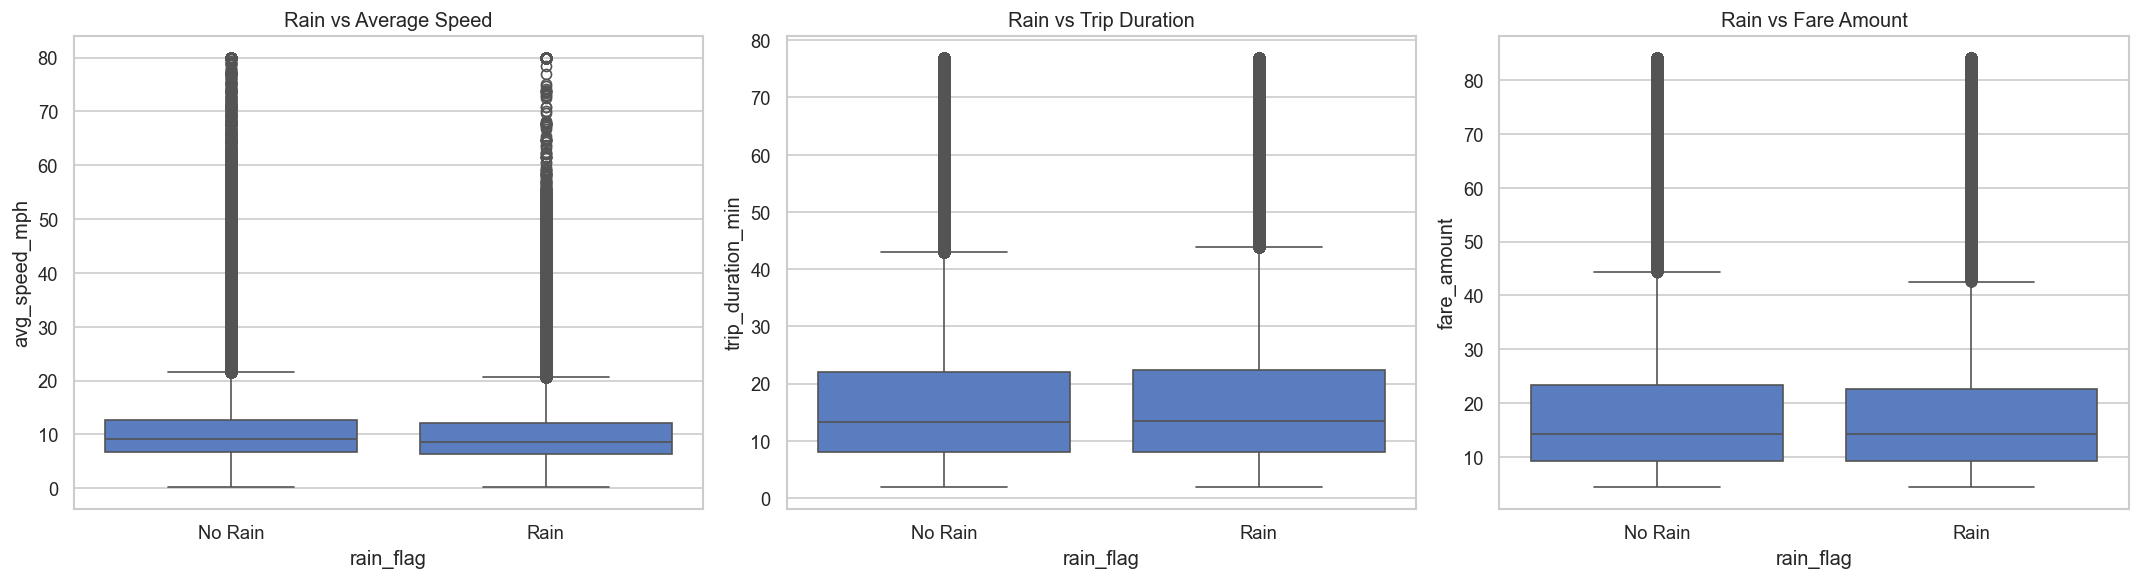

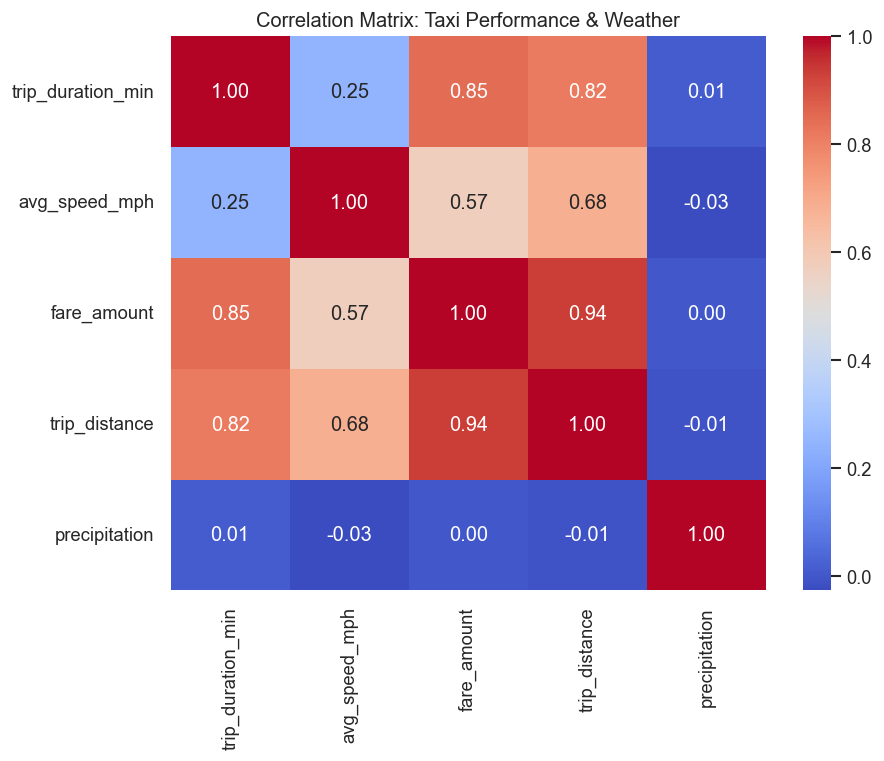

In [41]:
joint_df = df.copy()

joint_df = joint_df.dropna(subset=[
    "trip_duration_min",
    "avg_speed_mph",
    "fare_amount",
    "trip_distance",
    "precipitation"
])

joint_df["rain_flag"] = np.where(joint_df["precipitation"] > 0, 1, 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x="rain_flag", y="avg_speed_mph", data=joint_df, ax=axes[0])
axes[0].set_title("Rain vs Average Speed")
axes[0].set_xticklabels(["No Rain", "Rain"])

sns.boxplot(x="rain_flag", y="trip_duration_min", data=joint_df, ax=axes[1])
axes[1].set_title("Rain vs Trip Duration")
axes[1].set_xticklabels(["No Rain", "Rain"])

sns.boxplot(x="rain_flag", y="fare_amount", data=joint_df, ax=axes[2])
axes[2].set_title("Rain vs Fare Amount")
axes[2].set_xticklabels(["No Rain", "Rain"])

plt.tight_layout()
plt.show()

cor_matrix = joint_df[[
    "trip_duration_min",
    "avg_speed_mph",
    "fare_amount",
    "trip_distance",
    "precipitation"
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: Taxi Performance & Weather")
plt.show()

Rain is associated with slightly lower average speeds and marginally longer trip durations, indicating modest traffic slowdowns during precipitation events. Fare amounts show a small upward shift under rainy conditions, consistent with longer travel times and potential congestion effects, though overall differences remain moderate rather than dramatic.

Trip duration and fare amount exhibit a strong positive correlation (0.85), while average speed is strongly associated with trip distance (0.82), reflecting consistent underlying trip mechanics. Precipitation shows near-zero correlation with core performance variables, suggesting that its effects are likely nonlinear or context-dependent rather than directly linear.


## 6. Export Final Clean Dataset

In [43]:
#Select final columns for the clean processed dataset
final_cols = [
    # Core trip features
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'pickup_hour', 'pickup_hour_num', 'pickup_dayofweek', 'pickup_month_num',
    'trip_distance', 'trip_duration_min', 'fare_amount', 'tip_amount',
    'total_amount', 'passenger_count', 'payment_type', 'payment_label',
    'PULocationID', 'DOLocationID', 'RatecodeID',
    # Weather
    'temperature_2m', 'precipitation', 'windspeed_10m', 'cloudcover',
    # Engineered features
    'rush_hour', 'is_weekend', 'precip_category',
    'temp_deviation', 'distance_per_dollar', 'tip_rate', 'avg_speed_mph',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'cloudcover_norm', 'store_fwd_encoded',
] + [c for c in df.columns if c.startswith('precip_') and c != 'precip_category'] \
  + [c for c in df.columns if c.endswith('_std')]

# Keep only columns that exist in df
final_cols = [c for c in final_cols if c in df.columns]

df_final = df[final_cols].reset_index(drop=True)
# print(f'Final dataset shape: {df_final.shape}')

# Save
output_path = os.path.join(BASE_PATH, 'taxi_weather_cleaned_features.csv')
df_final.to_csv(output_path, index=False)

This project developed a comprehensive data pipeline integrating large-scale NYC taxi trip records with historical weather observations to support exploratory analysis and downstream predictive applications.

Through systematic cleaning, preprocessing, and feature engineering, raw multi-source data was transformed into an analysis-ready dataset capable of revealing structural patterns in urban mobility. The results underscore that taxi behavior is shaped not only by temporal rhythms but also by environmental conditions that influence travel decisions.

Beyond descriptive insight, the engineered feature set establishes a strong analytical foundation for future modeling tasks such as demand forecasting, travel-time estimation, and anomaly detection.

More broadly, this work illustrates that the reliability of analytical conclusions depends fundamentally on rigorous data preparation. High-quality insights are rarely the product of modeling alone — they are enabled by disciplined data engineering practices that ensure the signals being analyzed reflect genuine real-world behavior.

### 7. Feature Engineering

The feature engineering process expanded the cleaned and merged dataset to enhance analytical depth and modeling capability. The initial dataset contained **14,415,744 observations and 48 variables**. Through systematic transformation and augmentation, the dataset was expanded to **68 variables**, reflecting the addition of derived temporal, weather-related, spatial, and efficiency-based features.

Temporal features were generated to capture cyclical patterns and structured time effects, including sine transformations of hour and day-of-week, weekend and holiday indicators, and segmented time-of-day categories. Weather-related features were refined to represent rainfall intensity and severe traffic-weather interactions. Spatial indicators were incorporated to identify airport-related trips and pickup location frequency patterns. Efficiency and behavioral metrics were also constructed, including average speed, cost per mile, and tip percentage.

In total, a comprehensive set of engineered variables was added to enrich explanatory power and predictive readiness. The finalized dataset was saved as **`taxi_weather_engineered.parquet`**, preserving the expanded feature space for downstream statistical modeling and evaluation.

Working with multi-million-row transportation data required careful memory management and structured transformation design to maintain computational efficiency while preserving analytical integrity.


In [44]:
import pandas as pd
import numpy as np
from pandas.tseries.holiday import USFederalHolidayCalendar

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
# print("Loading dataset...")
# Using the engine that successfully worked for you
try:
    df = pd.read_parquet('taxi_weather_cleaned_features.parquet', engine='fastparquet')
except:
    df = pd.read_parquet('taxi_weather_cleaned_features.parquet', engine='pyarrow')

# Ensure Datetime formatting
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
if 'tpep_dropoff_datetime' in df.columns:
    df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# print(f"Initial Data Shape: {df.shape}")

# ==========================================
# 2. TEMPORAL FEATURES (Cyclical & Categorical)
# ==========================================
# print("Generating Temporal Features...")

# A. Basic Time Components
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_dow'] = df['tpep_pickup_datetime'].dt.dayofweek  # 0=Mon, 6=Sun
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

# B. Cyclical Encoding (The "Mathematical" way to represent time)
# Maps 23:00 and 00:00 as close to each other
df['hour_sin'] = np.sin(2 * np.pi * df['pickup_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['pickup_hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['pickup_dow'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['pickup_dow'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['pickup_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['pickup_month'] / 12)

# C. Logic-Based Time Flags
df['is_weekend'] = df['pickup_dow'].isin([5, 6]).astype(int)

# D. Federal Holidays (Specific to 2025)
# Holidays often look like weekends in data patterns
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=df['tpep_pickup_datetime'].min(), end=df['tpep_pickup_datetime'].max())
df['is_holiday'] = df['tpep_pickup_datetime'].dt.normalize().isin(holidays).astype(int)

# E. Time of Day Segments
# More granular than just "Rush Hour"
def get_time_segment(h):
    if 6 <= h < 10: return 'Morning_Rush'
    elif 10 <= h < 16: return 'Work_Hours'
    elif 16 <= h < 20: return 'Evening_Rush'
    elif 20 <= h < 24: return 'Evening_Leisure'
    else: return 'Late_Night'

df['time_segment'] = df['pickup_hour'].apply(get_time_segment)

# ==========================================
# 3. WEATHER FEATURES (Interactions & Indices)
# ==========================================
# print("Generating Weather Features...")

# A. Precipitation Intensity
if 'precipitation' in df.columns:
    df['has_rain'] = (df['precipitation'] > 0).astype(int)
    # Log transform for skewed rain data (useful for regression models)
    df['precipitation_log'] = np.log1p(df['precipitation'])
    
    # Categorical Bins
    df['rain_intensity'] = pd.cut(
        df['precipitation'], 
        bins=[-1, 0, 0.5, 2.5, 100], 
        labels=['None', 'Trace', 'Light', 'Heavy']
    )

# B. "Comfort" Index (Approximation)
# High winds + Cold temp = Uncomfortable (Low demand for walking, high for taxis)
if 'temperature_2m' in df.columns and 'windspeed_10m' in df.columns:
    # Simple wind chill proxy logic
    df['is_windy_cold'] = ((df['temperature_2m'] < 5) & (df['windspeed_10m'] > 15)).astype(int)

# C. Traffic x Weather Interaction
# Heavy Rain during Evening Rush is the "worst case" scenario
df['severe_traffic_weather'] = (
    (df['rain_intensity'] == 'Heavy') & 
    (df['time_segment'] == 'Evening_Rush')
).astype(int)

# ==========================================
# 4. SPATIAL & AIRPORT FEATURES
# ==========================================
# print("Generating Spatial Features...")

# A. Airport Detection (Specific NYC LocationIDs)
# 132: JFK, 138: LaGuardia, 1: Newark
airport_ids = [132, 138, 1]
df['is_airport_pickup'] = df['PULocationID'].isin(airport_ids).astype(int)
df['is_airport_dropoff'] = df['DOLocationID'].isin(airport_ids).astype(int)
df['is_airport_trip'] = (df['is_airport_pickup'] | df['is_airport_dropoff'])

# B. Location Popularity (Frequency Encoding)
# Replaces categorical ID with its probability density
for col in ['PULocationID', 'DOLocationID']:
    freq_map = df[col].value_counts(normalize=True)
    df[f'{col}_freq'] = df[col].map(freq_map)

# ==========================================
# 5. EFFICIENCY & PRICING METRICS
# ==========================================
# print("Generating Efficiency Metrics...")

# A. Trip Duration & Speed
# Convert duration to hours
if 'trip_duration_min' in df.columns:
    df['duration_hours'] = df['trip_duration_min'] / 60
else:
    # Fallback calculation if column missing
    df['duration_hours'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 3600

# Average Speed (mph)
df['avg_speed_mph'] = df['trip_distance'] / df['duration_hours'].replace(0, np.nan)

# Clean unrealistic speeds (Traffic in NYC < 60mph usually, allowing buffer for highway)
df.loc[df['avg_speed_mph'] > 85, 'avg_speed_mph'] = np.nan
df.loc[df['avg_speed_mph'] < 0.1, 'avg_speed_mph'] = np.nan # Remove stationary noise

# B. Fare Efficiency (Cost per Mile)
df['cost_per_mile'] = df['total_amount'] / df['trip_distance'].replace(0, np.nan)
# Filter logical bounds ($2.50 base fare minimum implies high cost/mile for short trips)
df.loc[df['cost_per_mile'] > 50, 'cost_per_mile'] = np.nan 

# C. Tipping Behavior
# Tip % = Tip / (Total - Tip). We remove the tip from the denominator to get the base bill.
base_bill = df['total_amount'] - df['tip_amount']
df['tip_percentage'] = (df['tip_amount'] / base_bill.replace(0, np.nan)) * 100
df['tip_percentage'] = df['tip_percentage'].fillna(0)

# D. High Value Trip Flag
# Arbitrary threshold (e.g., trips over $50)
df['is_high_value_trip'] = (df['total_amount'] > 50).astype(int)

# ==========================================
# 6. FINAL CLEANUP & SAVE
# ==========================================
# Drop intermediate calculation columns
cols_to_drop = ['duration_hours']
df_final = df.drop(columns=cols_to_drop, errors='ignore')

# Drop rows with NaNs generated by Lag/Shift/Division (optional, based on your preference)
# df_final.dropna(inplace=True) 

# print("-" * 30)
# print("Feature Engineering Complete.")
# print(f"Final Data Shape: {df_final.shape}")
# print("New Features Added:")
# print([
#     'hour_sin', 'dow_sin', 'is_weekend', 'is_holiday', 'time_segment',
#     'rain_intensity', 'severe_traffic_weather', 'is_airport_trip',
#     'avg_speed_mph', 'cost_per_mile', 'tip_percentage', 'PULocationID_freq'
# ])

# Save using the robust engine
df_final.to_parquet('taxi_weather_engineered.parquet', engine='fastparquet') 
# print("\nSaved to 'taxi_weather_engineered.parquet'")



Working with multi-million-row transportation data introduced both technical and methodological challenges.

**Temporal alignment.**  
Taxi trips occur at high frequency, whereas weather observations are reported at coarser intervals. Although careful joins were implemented, future work could leverage station-level weather data and spatial matching to further improve alignment accuracy.

**Data anomalies.**  
Urban mobility datasets inevitably contain extreme observations. While logical filtering improved statistical stability, future analyses could model anomalies explicitly rather than removing them, thereby preserving rare but meaningful behavioral events.

**Computational scale.**  
The size of the dataset necessitated efficiency-conscious processing strategies. Future extensions may benefit from distributed computing frameworks to support longer temporal windows or multi-city comparisons.

**Modeling extensions.**  
Although this project focused on exploratory preparation, the engineered dataset is well-suited for machine learning applications including demand forecasting, surge prediction, and weather-aware mobility modeling.


## 8. Analyze and Visualize Features

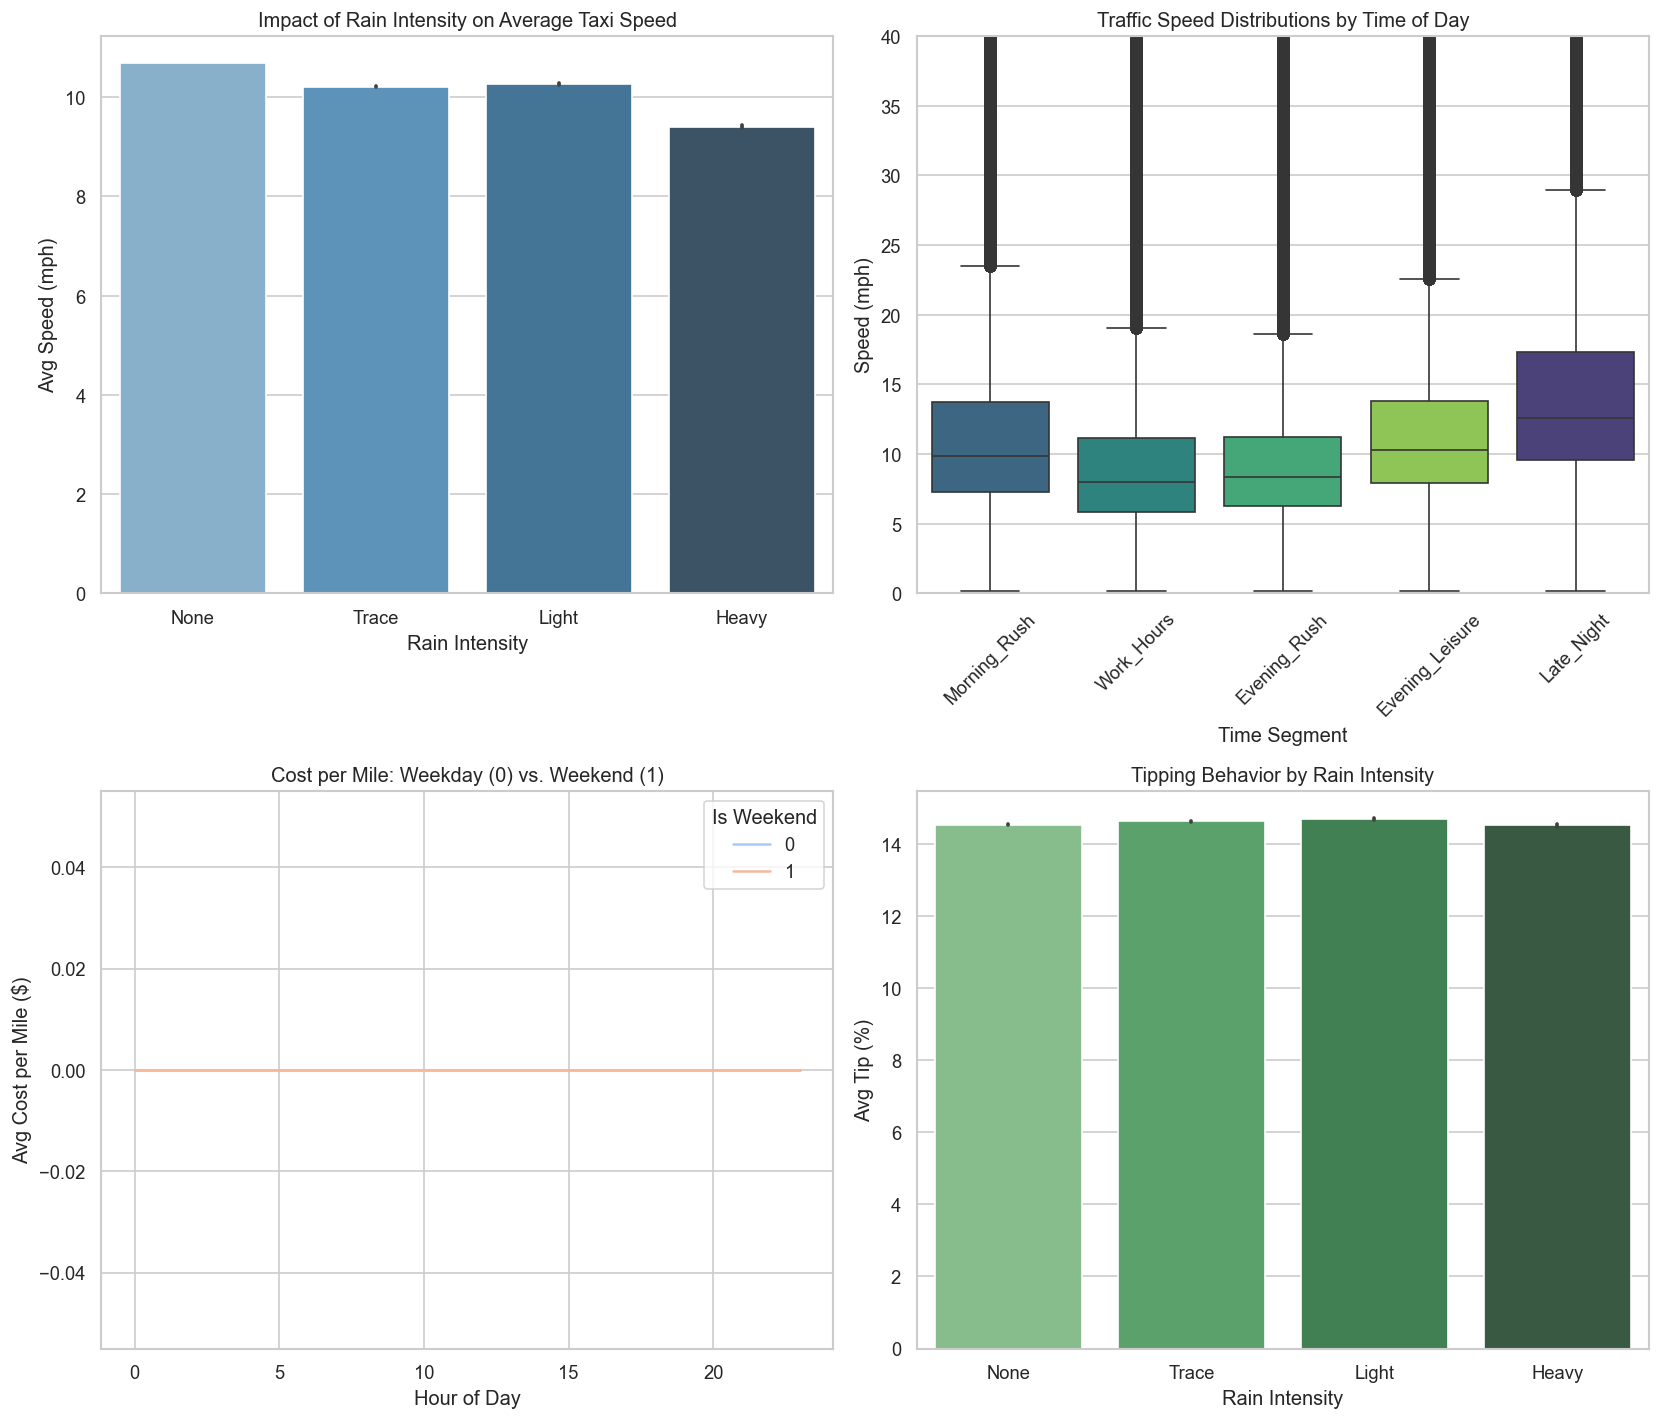

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Engineered Data
df = pd.read_parquet('taxi_weather_engineered.parquet', engine='fastparquet') # or 'pyarrow'

# Set plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 12))

# -------------------------------------------------------
# ANALYSIS 1: WEATHER IMPACT ON TRAFFIC SPEED
# -------------------------------------------------------
plt.subplot(2, 2, 1)
# FIX: Assigned x to hue and set legend=False
sns.barplot(
    data=df, 
    x='rain_intensity', 
    y='avg_speed_mph', 
    hue='rain_intensity',  # <--- Fixes the warning
    palette='Blues_d', 
    order=['None', 'Trace', 'Light', 'Heavy'],
    legend=False           # <--- Hides the redundant legend
)
plt.title('Impact of Rain Intensity on Average Taxi Speed')
plt.xlabel('Rain Intensity')
plt.ylabel('Avg Speed (mph)')

# -------------------------------------------------------
# ANALYSIS 2: RUSH HOUR vs. OFF-PEAK EFFICIENCY
# -------------------------------------------------------
plt.subplot(2, 2, 2)
# FIX: Assigned x to hue and set legend=False
sns.boxplot(
    data=df, 
    x='time_segment', 
    y='avg_speed_mph', 
    hue='time_segment',  # <--- Fixes the warning
    palette='viridis', 
    order=['Morning_Rush', 'Work_Hours', 'Evening_Rush', 'Evening_Leisure', 'Late_Night'],
    legend=False
)
plt.title('Traffic Speed Distributions by Time of Day')
plt.xticks(rotation=45)
plt.xlabel('Time Segment')
plt.ylabel('Speed (mph)')
plt.ylim(0, 40) # Limit y-axis to remove outliers

# -------------------------------------------------------
# ANALYSIS 3: COST EFFICIENCY (FARE PER MILE)
# -------------------------------------------------------
plt.subplot(2, 2, 3)
# Group by Hour and Weekend Status for the line plot
hourly_cost = df.groupby(['pickup_hour', 'is_weekend'])['cost_per_mile'].mean().reset_index()

sns.lineplot(
    data=hourly_cost, 
    x='pickup_hour', 
    y='cost_per_mile', 
    hue='is_weekend', # hue is already correctly used here for different lines
    palette='coolwarm'
)
plt.title('Cost per Mile: Weekday (0) vs. Weekend (1)')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Cost per Mile ($)')
plt.legend(title='Is Weekend')

# -------------------------------------------------------
# ANALYSIS 4: TIPPING BEHAVIOR BY WEATHER
# -------------------------------------------------------
plt.subplot(2, 2, 4)
# FIX: Assigned x to hue and set legend=False
sns.barplot(
    data=df, 
    x='rain_intensity', 
    y='tip_percentage', 
    hue='rain_intensity', # <--- Fixes the warning
    palette='Greens_d', 
    order=['None', 'Trace', 'Light', 'Heavy'],
    legend=False
)
plt.title('Tipping Behavior by Rain Intensity')
plt.xlabel('Rain Intensity')
plt.ylabel('Avg Tip (%)')

plt.tight_layout()
plt.savefig('feature_analysis_plots.png')
plt.show()

# print("Analysis Complete. Plot saved as 'feature_analysis_plots.png'.")

**Impact of Rain Intensity on Average Taxi Speed.**
Average speed declines as rain intensity increases, with the most noticeable drop under heavy rain conditions. This suggests that adverse weather meaningfully slows urban traffic flow.

**Traffic Speed Distributions by Time of Day.**
Speeds are lowest and more variable during work and rush-hour periods, while late-night segments exhibit the highest median speeds and wider upper ranges. This reflects reduced congestion during off-peak hours.

**Cost per Mile: Weekday vs. Weekend.**
Cost per mile varies by hour and differs modestly between weekdays and weekends, with weekdays showing sharper peaks during high-demand hours. The convergence in late evening suggests pricing stabilizes when demand patterns normalize.

**Tipping Behavior by Rain Intensity.**
Average tip percentages appear relatively stable across rain categories, indicating that tipping behavior is less sensitive to weather conditions compared to operational metrics like speed or duration.


In [47]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Load the Data
try:
    df = pd.read_parquet('taxi_weather_engineered.parquet', engine='fastparquet')
except:
    df = pd.read_parquet('taxi_weather_engineered.parquet', engine='pyarrow')

# 2. Define Potential Columns to Scale
# We list everything we *want* to scale, but we won't assume they all exist.
potential_features = [
    'trip_distance', 'fare_amount', 'tip_amount', 'total_amount', 
    'temperature_2m', 'precipitation', 'windspeed_10m', 
    'duration_hours', 'avg_speed_mph', 'cost_per_mile',
    'trip_duration_min' # Adding this as a fallback for duration_hours
]

# 3. Select Only Columns That Actually Exist in Dataframe
features_to_scale = [col for col in potential_features if col in df.columns]

# print(f"Columns found for scaling: {features_to_scale}")

# 4. Apply Scaling
if features_to_scale:
    scaler = StandardScaler()
    df_scaled = df.copy()
    
    # Handle infinite values before scaling (Scaling fails on infinity)
    # Replace inf with NaN, then fill NaN with mean
    import numpy as np
    df_scaled.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_scaled[features_to_scale] = df_scaled[features_to_scale].fillna(df_scaled[features_to_scale].mean())
    
    # Perform the scaling
    df_scaled[features_to_scale] = scaler.fit_transform(df_scaled[features_to_scale])
    
    # print("-" * 30)
    # print("Data Preprocessing (Scaling) Complete.")
    # print("Example of scaled 'trip_distance' (mean should be ~0):")
    # print(df_scaled['trip_distance'].head())
    
    # Save the scaled data if needed for modeling later
    # df_scaled.to_parquet('taxi_weather_scaled.parquet')


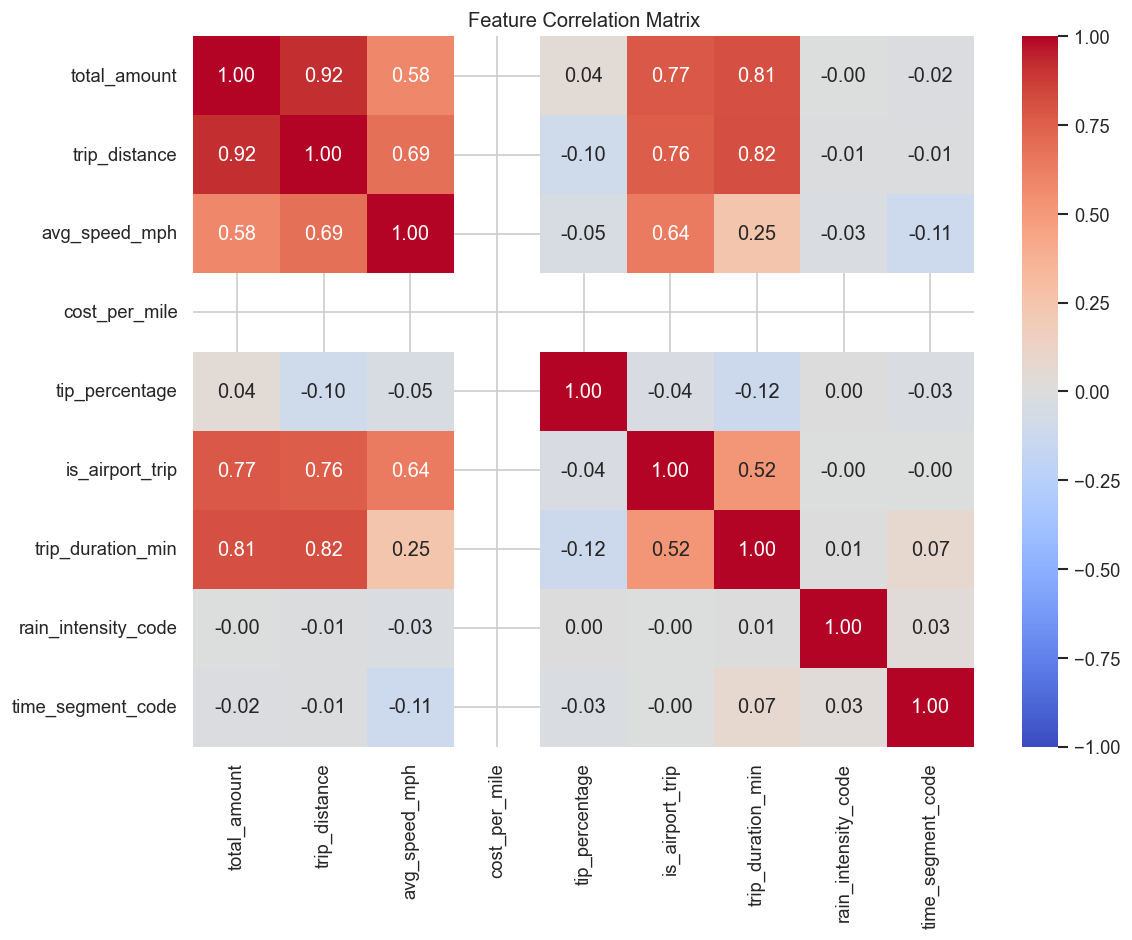

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the columns we WANT to check
# We include alternatives (e.g., trip_duration_min instead of duration_hours)
preferred_cols = [
    'total_amount', 'trip_distance', 'avg_speed_mph', 'cost_per_mile',
    'tip_percentage', 'is_airport_trip', 
    'duration_hours', 'trip_duration_min', # Alternative pairs
    'is_rush_hour', 'time_segment',        # Alternative pairs
    'bad_weather_flag', 'rain_intensity'   # Weather features
]

# 2. Dynamic Feature Selection
# Only keep columns that actually exist in your dataframe
available_cols = [c for c in preferred_cols if c in df.columns]

# print(f"Columns available for correlation: {available_cols}")

# 3. Handle Categorical Columns for Correlation
# We need to convert categories (like 'Heavy' rain) to numbers (0, 1, 2)
df_corr = df[available_cols].copy()

# Handle Rain Intensity
if 'rain_intensity' in df_corr.columns:
    # Convert category to code (0, 1, 2...)
    df_corr['rain_intensity_code'] = df_corr['rain_intensity'].astype('category').cat.codes
    # Replace the original column in our list with the encoded one
    available_cols.remove('rain_intensity')
    available_cols.append('rain_intensity_code')

# Handle Time Segment (if is_rush_hour is missing)
if 'time_segment' in df_corr.columns:
    df_corr['time_segment_code'] = df_corr['time_segment'].astype('category').cat.codes
    available_cols.remove('time_segment')
    available_cols.append('time_segment_code')

# 4. Calculate Correlation
# Use the updated list of columns
corr_matrix = df_corr[available_cols].corr()

# 5. Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

Strong positive correlations appear among core trip metrics: total amount, trip distance, and trip duration (≈0.8–0.9), confirming that longer trips naturally drive higher fares and totals. Airport trips are also strongly associated with longer distances and durations, while weather variables (rain intensity, time segment) show comparatively weak linear correlations, suggesting their effects may be nonlinear or interaction-based rather than directly proportional.


## Conclusion

This project developed a comprehensive data pipeline integrating large-scale New York City taxi trip records with historical weather observations to support exploratory analysis and future predictive modeling. By systematically acquiring, cleaning, and harmonizing multi-source data, the project transformed raw transactional records into a structured and analytically reliable dataset.

Exploratory analysis revealed that urban mobility is strongly governed by temporal rhythms, with recurring patterns across hourly and weekly cycles reflecting the behavioral regularities of commuters and city travelers. At the same time, environmental conditions such as precipitation and temperature introduce measurable variability into trip dynamics, reinforcing the importance of contextual data when analyzing transportation systems.

The feature engineering process operationalized these insights by embedding temporal structure and weather-aware indicators directly into the dataset. These engineered variables enhance interpretability while positioning the dataset for higher-fidelity modeling tasks, including demand forecasting, travel-time estimation, and anomaly detection.

More broadly, this project demonstrates that rigorous data preparation is not merely a preliminary step but a foundational component of trustworthy analysis. Meaningful insights rarely emerge from raw data alone; rather, they are enabled through disciplined cleaning, thoughtful feature construction, and analytically grounded exploration.

Overall, the resulting dataset provides a robust platform for future investigations into urban mobility behavior and supports data-driven approaches to understanding how environmental and temporal factors jointly shape transportation patterns.

